Em andamento ...

# Heart Disease Dataset 
(Dataset disponível em > [Kaggle](https://www.kaggle.com/datasets/johnsmith88/heart-disease-dataset?resource=download) <)

A principal ideia desse Dataset é de alguma maneira conseguir preditar um indíviduo possivelmente com alguma doença cardíaca a partir de 

fatores pessoiais. 


Esse Dataset reúne dados de 1988 de 4 lugares diferentes, sendo eles: Cleveland, Hungary, Switzerland e Long Beach V. As colunas são compostas por essas 14 variáveis:



1. **Idade**

2. **Sexo**

3. **Tipo_de_dor_no_peito (4 valores possíveis)**

4. **Pressao_arterial_em_repouso**

5. **Colesterol_serico_mg_dl**

6. **Glicemia_de_jejum_maior_120mg_dl**

7. **Eletrocardiograma_repouso (valores: 0, 1, 2)**

8. **Frequencia_cardiaca_maxima**

9. **Angina_induzida_por_exercicio**

10. **Oldpeak (depressão do segmento ST induzida pelo exercício em relação ao repouso)**

11. **Inclinacao_ST_pico_exercicio**

12. **Numero_grandes_vasos_fluorescencia (valores: 0–3)**

13. **Escala_defeito (0 = normal; 1 = defeito fixo; 2 = defeito reversível)**


<span style="color:red">IMPORTANTE</span>

Mesmo que o Dataset apresente referências de coleta para aumentar sua veracidade, **ele** ainda pode **gerar desconfiança**.

Ao entrar na aba <span style="color:#c7c77d">Discussion</span> do Kaggle, nos deparamos com um <i>paper</i> que mostra a inconsistência desse Dataset em relação ao lugar de onde foi coletado: [paper](https://libres.uncg.edu/ir/ecsu/f/Brandon_Simmons_Thesis-Final.pdf). Veja um exemplo de inconsistência na imagem a seguir:

![image](images/paperex.png)

Então provavelmente o Dataset foi modificado para que modelos obtivessem resultados melhores.

Por exemplo:

Foi observado que muitos modelos classificavam errado específicos "x" instâncias não doentes como doentes,

logo foram alterados os seus targets.

Para contornar essa situação iremos "aleatorizar" um pouco nossas instâncias, removendo dados aleatoriamente e depois

fazendo um método de imputação

# Limpeza Inicial do Dataset

In [277]:
# Importações Iniciais

import numpy as np
import pandas as pd

In [278]:
# Carregando Dataset

heart_ds = pd.read_csv("data/heart.csv")
heart_ds.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [279]:
len(heart_ds)

1025

In [280]:
heart_ds.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
1020     True
1021     True
1022     True
1023     True
1024     True
Length: 1025, dtype: bool

In [281]:
heart_ds = heart_ds.drop_duplicates()
len(heart_ds)

302

Temos inicialmente 1025 pacientes para analisar, porém ao analisarmos mais a fundo vemos que vários desses dados são dados duplicados, ou seja, são apenas linhas repetidas, e elaborar modelos com Datasets com dados repetidos é péssimo, já que dessa maneira estamos enviesando a distribuição dos dados.

# Delete e Imputação de Dados

In [282]:
# Apagando dados aleatórios

base = heart_ds.copy()
fonte = "heart_ds (kernel)"

print(f"Fonte de dados: {fonte} - shape: {base.shape}")

# 2) Definir coluna alvo (não apagaremos o alvo para manter a tarefa de classificação)
if 'target' in base.columns:
    target_col = 'target'

# 3) Copiar e aplicar máscara aleatória de 20% (por célula), exceto na coluna alvo
rng = np.random.default_rng(42)
mask = rng.random(base.shape) < 0.1
if target_col in base.columns:
    target_idx = base.columns.get_loc(target_col)
    mask[:, target_idx] = False

heart_ds_missing = base.copy()
# Aplicar NaN com base na máscara (funciona para numéricos e também converte ints para float quando necessário)
heart_ds_missing = heart_ds_missing.mask(mask)

# 4) Relatório de faltantes por coluna
na_counts = heart_ds_missing.isna().sum()
print("Valores faltantes por coluna (após mascarar 20%):")
print(na_counts.to_string())

# 5) Pré-visualização
display(heart_ds_missing.head())

Fonte de dados: heart_ds (kernel) - shape: (302, 14)
Valores faltantes por coluna (após mascarar 20%):
age         35
sex         33
cp          33
trestbps    31
chol        28
fbs         24
restecg     36
thalach     30
exang       28
oldpeak     31
slope       20
ca          32
thal        30
target       0


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52.0,1.0,0.0,125.0,NaN,0.0,1.0,168.0,0.0,1.0,2.0,2.0,3.0,0
1,53.0,1.0,0.0,NaN,203.0,1.0,0.0,155.0,1.0,3.1,0.0,0.0,3.0,0
2,70.0,1.0,0.0,145.0,174.0,0.0,1.0,125.0,1.0,2.6,0.0,0.0,3.0,0
3,61.0,1.0,0.0,148.0,203.0,0.0,1.0,161.0,0.0,NaN,2.0,1.0,3.0,0
4,62.0,0.0,0.0,138.0,294.0,1.0,1.0,106.0,0.0,1.9,1.0,3.0,NaN,0


Vamos passar o Dataframe com os novos valores de <span style="color:yellow">NaN</span> para uma matriz e fazer então a imputação

In [283]:
def npar_to_df(Matrix:np.array) -> pd.DataFrame:
    dict_ = {}
    list_vars = ["age","sex","cp","trestbps","chol","fbs","restecg","thalach","exang","oldpeak","slope","ca","thal","target"]
    list_coluns = []
    for i in range(14):
        list_coluns.append(Matrix[i])
    for i in range(14):
        dict_[list_vars[i]] =  list_coluns[i]
    
    return pd.DataFrame(dict_)

    

In [284]:
from sklearn.preprocessing import StandardScaler
from sklearn.impute import KNNImputer
import pandas as pd

scaler = StandardScaler()
heart_scaled = scaler.fit_transform(heart_ds_missing)

imputer = KNNImputer(n_neighbors=5)
heart_imputed_scaled = imputer.fit_transform(heart_scaled)

heart_imputed = scaler.inverse_transform(heart_imputed_scaled)

heart_imputed = pd.DataFrame(heart_imputed, columns=heart_ds_missing.columns)

In [285]:
heart_imputed.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52.0,1.0,0.0,125.0,231.0,0.0,1.0,168.0,0.0,1.00,2.0,2.0,3.0,0.0
1,53.0,1.0,0.0,146.0,203.0,1.0,0.0,155.0,1.0,3.10,0.0,0.0,3.0,0.0
2,70.0,1.0,0.0,145.0,174.0,0.0,1.0,125.0,1.0,2.60,0.0,0.0,3.0,0.0
3,61.0,1.0,0.0,148.0,203.0,0.0,1.0,161.0,0.0,0.86,2.0,1.0,3.0,0.0
4,62.0,0.0,0.0,138.0,294.0,1.0,1.0,106.0,0.0,1.90,1.0,3.0,3.0,0.0


In [286]:
heart_imputed["sex"] = heart_imputed["sex"].apply(lambda x: 1 if x > 0.5 else 0)
heart_imputed["fbs"] = heart_imputed["fbs"].apply(lambda x: 1 if x > 0.5 else 0)
heart_imputed["exang"] = heart_imputed["exang"].apply(lambda x: 1 if x > 0.5 else 0)
heart_imputed["cp"]      = np.clip(np.round(heart_imputed["cp"]), 0, 3)
heart_imputed["restecg"] = np.clip(np.round(heart_imputed["restecg"]), 0, 2)
heart_imputed["slope"]   = np.clip(np.round(heart_imputed["slope"]), 0, 2)
heart_imputed["ca"]      = np.clip(np.round(heart_imputed["ca"]), 0, 4)
heart_imputed["thal"]    = np.clip(np.round(heart_imputed["thal"]), 0, 3)




In [287]:
heart_imputed["cp"]      = np.clip(np.round(heart_imputed["cp"]), 0, 3)
heart_imputed["restecg"] = np.clip(np.round(heart_imputed["restecg"]), 0, 2)
heart_imputed["slope"]   = np.clip(np.round(heart_imputed["slope"]), 0, 2)
heart_imputed["ca"]      = np.clip(np.round(heart_imputed["ca"]), 0, 4)
heart_imputed["thal"]    = np.clip(np.round(heart_imputed["thal"]), 0, 3)


# Análise Exploratória

In [288]:
# Informações
heart_imputed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 302 entries, 0 to 301
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       302 non-null    float64
 1   sex       302 non-null    int64  
 2   cp        302 non-null    float64
 3   trestbps  302 non-null    float64
 4   chol      302 non-null    float64
 5   fbs       302 non-null    int64  
 6   restecg   302 non-null    float64
 7   thalach   302 non-null    float64
 8   exang     302 non-null    int64  
 9   oldpeak   302 non-null    float64
 10  slope     302 non-null    float64
 11  ca        302 non-null    float64
 12  thal      302 non-null    float64
 13  target    302 non-null    float64
dtypes: float64(11), int64(3)
memory usage: 33.2 KB


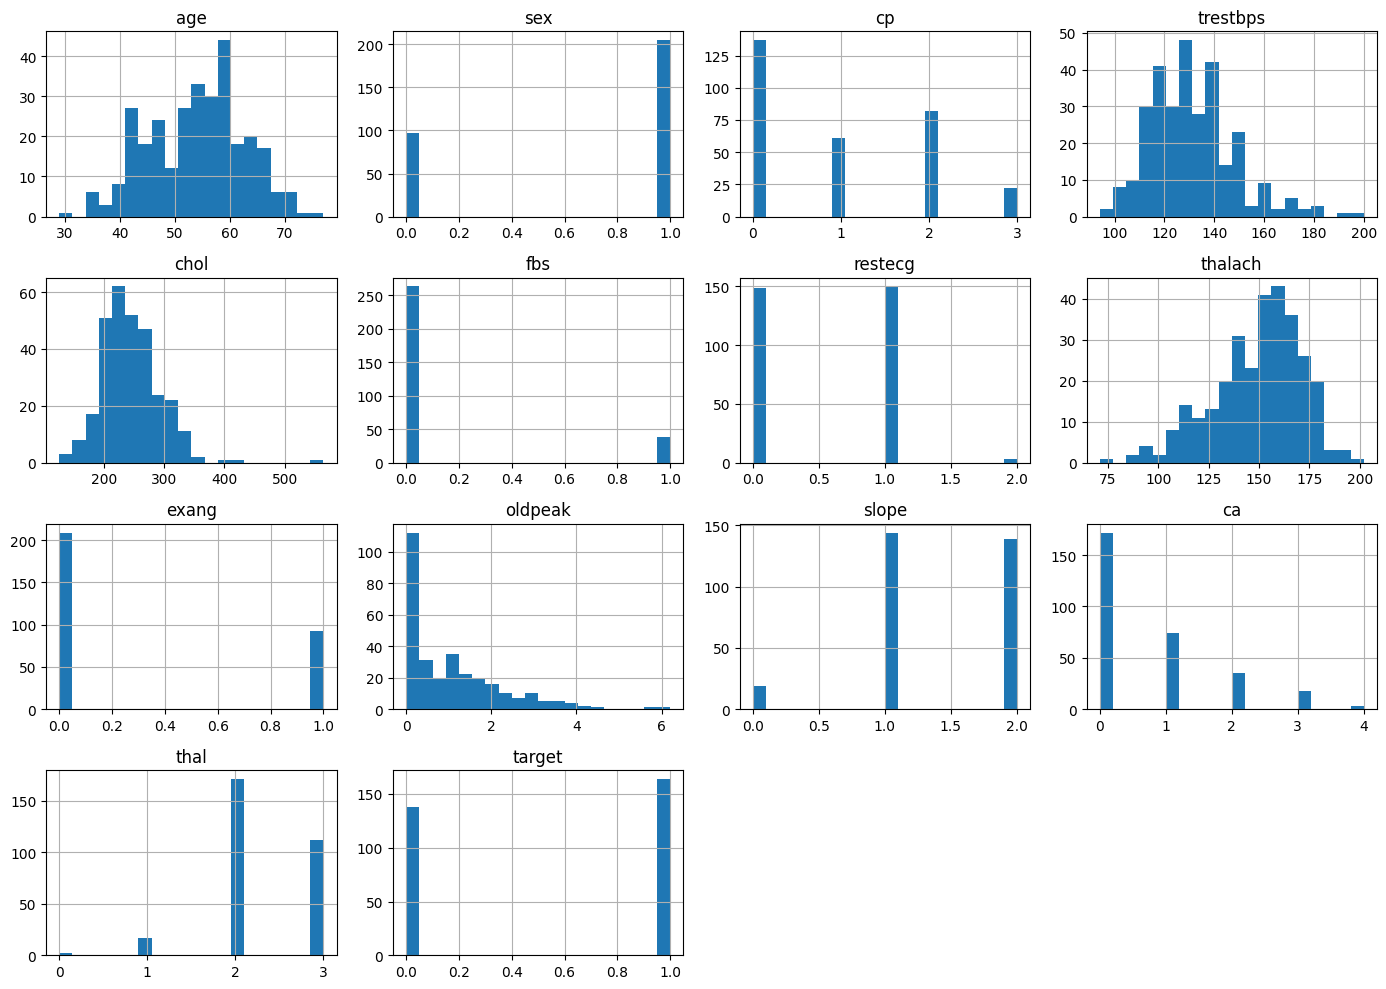

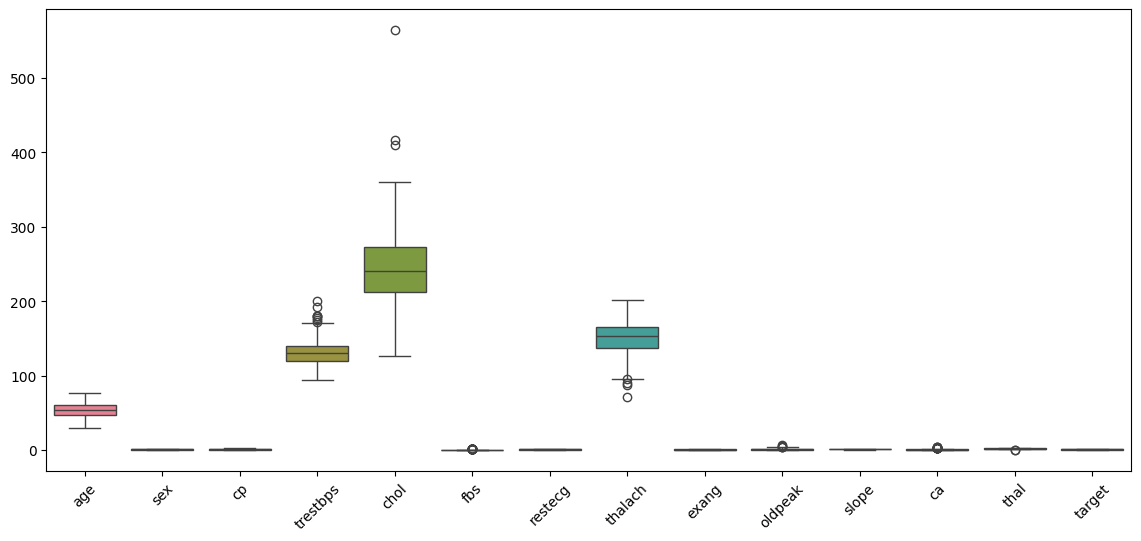

In [289]:
import matplotlib.pyplot as plt
import seaborn as sns

heart_imputed.hist(figsize=(14, 10), bins=20)
plt.tight_layout()
plt.show()

# Boxplots para verificar outliers
plt.figure(figsize=(14, 6))
sns.boxplot(data=heart_imputed.select_dtypes(include=np.number))
plt.xticks(rotation=45)
plt.show()
     


## Modelos de classificação para `target`:

Trata-se de uma classificação binária, então podemos fazer diversos modelos, aqui trataremos desses:
- Regressão Linear
- LDA
- QDA
- Regressão Logística
- KNN
- SVM
- Rede Neural

Por fim faremos a comparação fiel entre os modelos e qual seria mais adequado para essa devida tarefa.

In [290]:
class Classifier():
    def __init__(self,name,vars,metrics):
        self.name = name
        self.vars = vars
        self.metrics = metrics

### Regressão Linear (Classificação)

In [291]:
import numpy as np
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import statsmodels.api as sm
import matplotlib.pyplot as plt
import numpy as np

- A ideia da utilizaçao de regressão linear para classificação é tentar prever a variável alvo como uma variável categórica alvo como uma variável contínua e usar um limiar a partir do qual classificaremos o alvo como categórico. Se temos duas classes para prever, uma aproximação:

In [292]:
heart_ds = heart_imputed

OLS (apenas diagnóstico) - R² e summary:
R² (train): 0.573
                            OLS Regression Results                            
Dep. Variable:                 target   R-squared:                       0.573
Model:                            OLS   Adj. R-squared:                  0.526
Method:                 Least Squares   F-statistic:                     12.10
Date:                Mon, 10 Nov 2025   Prob (F-statistic):           5.06e-25
Time:                        19:37:37   Log-Likelihood:                -62.392
No. Observations:                 211   AIC:                             168.8
Df Residuals:                     189   BIC:                             242.5
Df Model:                          21                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------

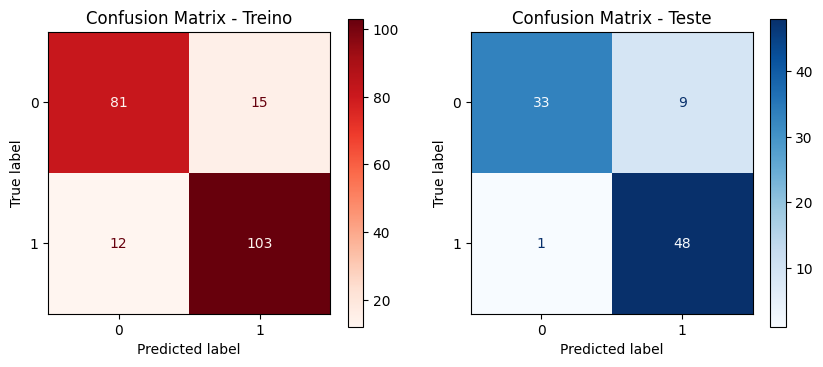

Acurácia no conjunto de treino: 0.872
Acurácia no conjunto de teste: 0.890 


Agora retiramos preditores com p-valor > 0.05 por meio de backward selection
Removendo 'ca_4.0' com p-valor 0.967
Removendo 'thal_1.0' com p-valor 0.957
Removendo 'fbs' com p-valor 0.892
Removendo 'slope_2.0' com p-valor 0.752
Removendo 'thal_3.0' com p-valor 0.565
Removendo 'restecg_1.0' com p-valor 0.496
Removendo 'restecg_2.0' com p-valor 0.420
Removendo 'chol' com p-valor 0.296
Removendo 'thalach' com p-valor 0.254
Removendo 'trestbps' com p-valor 0.180
                            OLS Regression Results                            
Dep. Variable:                 target   R-squared:                       0.561
Model:                            OLS   Adj. R-squared:                  0.536
Method:                 Least Squares   F-statistic:                     23.09
Date:                Mon, 10 Nov 2025   Prob (F-statistic):           4.58e-30
Time:                        19:37:37   Log-Likelihood:          

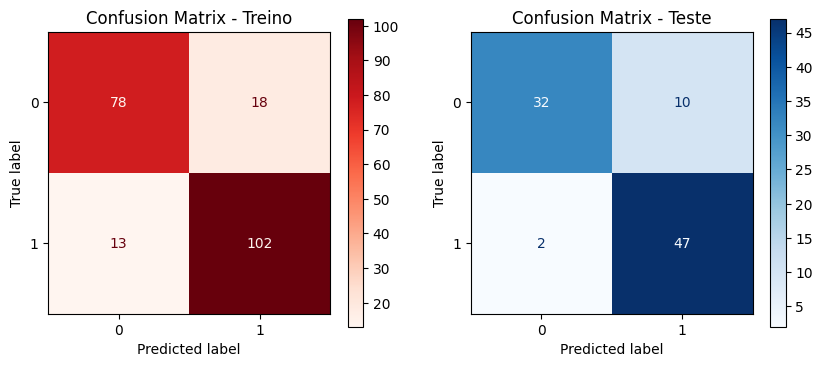

Acurácia no conjunto de treino: 0.853
Acurácia no conjunto de teste: 0.868 




In [293]:
X = heart_ds.drop(["target", "age"], axis=1)
y = heart_ds["target"]

categorical_cols = ['cp', 'thal', 'slope', 'restecg', "ca"]
categorical_cols = [c for c in categorical_cols if c in X.columns]
if len(categorical_cols) > 0:
    X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

scalizer = StandardScaler() # normaliza os dados e reduz a variancia dos coeficientes
X = pd.DataFrame(scalizer.fit_transform(X), columns=X.columns)

X_const = sm.add_constant(X) # aciciona constante para o intercepto

X_train, X_test, y_train, y_test = train_test_split(X_const, y, test_size=0.3, random_state=200, stratify=y)

X_train = X_train.astype(float)
X_test = X_test.astype(float)
y_train = y_train.astype(float)
y_test = y_test.astype(float)
model_ols = sm.OLS(y_train, X_train).fit()
print("OLS (apenas diagnóstico) - R² e summary:")
print(f"R² (train): {model_ols.rsquared:.3f}")
print(model_ols.summary())
print("\nmatriz de covariância dos coeficientes:")
print(model_ols.cov_params())

y_pred_train = model_ols.predict(X_train)
y_pred_test  = model_ols.predict(X_test)

y_pred_train = np.where(y_pred_train > 0.5, 1, 0)
y_pred_test  = np.where(y_pred_test  > 0.5, 1, 0)

for i in range(len(y_pred_train)):
    if y_pred_train[i] <= 0.5:
        y_pred_train[i] = 0
    else:
        y_pred_train[i] = 1


fig, axes = plt.subplots(1, 2, figsize=(10, 4))

cm = confusion_matrix(y_train, y_pred_train)
cm_display_train = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
cm_display_train.plot(cmap=plt.cm.Reds, ax=axes[0])
axes[0].set_title("Confusion Matrix - Treino")

for i in range(len(y_pred_test)):
    if y_pred_test[i] <= 0.5:
        y_pred_test[i] = 0
    else:
        y_pred_test[i] = 1

cm = confusion_matrix(y_test, y_pred_test)
cm_display_test = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
cm_display_test.plot(cmap=plt.cm.Blues, ax=axes[1])
axes[1].set_title("Confusion Matrix - Teste")
plt.show()

acc = accuracy_score(y_train, y_pred_train)
print(f"Acurácia no conjunto de treino: {acc:.3f}")
acc = accuracy_score(y_test, y_pred_test)
print(f"Acurácia no conjunto de teste: {acc:.3f} \n\n")

print(f'Agora retiramos preditores com p-valor > 0.05 por meio de backward selection')

X_opt = X_train.copy()
X_opt_test = X_test.copy()
threshold = 0.05

while True:
    model = sm.OLS(y_train, X_opt).fit()
    pvals = model.pvalues.drop("const", errors="ignore")
    worst_pval = pvals.max()
    if worst_pval > threshold:
        worst_var = pvals.idxmax()
        print(f"Removendo '{worst_var}' com p-valor {worst_pval:.3f}")
        X_opt = X_opt.drop(columns=[worst_var])
        X_opt_test = X_opt_test.drop(columns=[worst_var])
    else:
        break

model_final = sm.OLS(y_train, X_opt).fit()

print(model_final.summary())
print("\nmatriz de covariância dos coeficientes:")
print(model_final.cov_params())

y_pred_train = model_final.predict(X_opt)
y_pred_test  = model_final.predict(X_opt_test)

y_pred_train = np.where(y_pred_train > 0.5, 1, 0)
y_pred_test  = np.where(y_pred_test  > 0.5, 1, 0)

for i in range(len(y_pred_train)):
    if y_pred_train[i] <= 0.5:
        y_pred_train[i] = 0
    else:
        y_pred_train[i] = 1


fig, axes = plt.subplots(1, 2, figsize=(10, 4))

cm = confusion_matrix(y_train, y_pred_train)
cm_display_train = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
cm_display_train.plot(cmap=plt.cm.Reds, ax=axes[0])
axes[0].set_title("Confusion Matrix - Treino")

for i in range(len(y_pred_test)):
    if y_pred_test[i] <= 0.5:
        y_pred_test[i] = 0
    else:
        y_pred_test[i] = 1

cm = confusion_matrix(y_test, y_pred_test)
cm_display_test = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
cm_display_test.plot(cmap=plt.cm.Blues, ax=axes[1])
axes[1].set_title("Confusion Matrix - Teste")
plt.show()

acc = accuracy_score(y_train, y_pred_train)
print(f"Acurácia no conjunto de treino: {acc:.3f}")
acc = accuracy_score(y_test, y_pred_test)
print(f"Acurácia no conjunto de teste: {acc:.3f} \n\n")


Podemos ver que após o `backward selection`, as variâncias dos estimadores em geral diminuiu devido à remoçao de algumas variáveis que apresentavam dependências lineares entre si. 

Para comparar nosso modelo com outros, é importante obter uma estimativa mais robustas de seu desempenho médio.

Para isso, utilizaremos a validação cruzada `(cross-validation)`, aplicando a regressão linear em cinco divisões `(5-folds)` diferentes dos dados.

Esse método fornece uma estimativa mais confiável da performance média do modelo, pois reduz a influência da divisão específica dos dados em treino e teste, além de representar melhor sua capacidade de generalização ou seja, o risco de erro ao aplicar o modelo em novos dados.

Removendo 'ca_4.0' com p-valor 0.842
Removendo 'slope_1.0' com p-valor 0.780
Removendo 'fbs' com p-valor 0.749
Removendo 'thalach' com p-valor 0.549
Removendo 'thal_1.0' com p-valor 0.436
Removendo 'thal_3.0' com p-valor 0.661
Removendo 'cp_3.0' com p-valor 0.437
Removendo 'chol' com p-valor 0.370
Removendo 'restecg_1.0' com p-valor 0.240
Removendo 'restecg_2.0' com p-valor 0.192
Removendo 'cp_1.0' com p-valor 0.152
Removendo 'slope_2.0' com p-valor 0.163
Removendo 'sex' com p-valor 0.069
Removendo 'trestbps' com p-valor 0.075


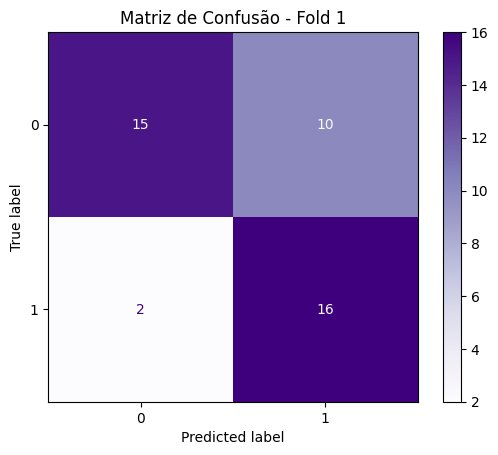

Fold 1 - Acc: 0.721 | Prec: 0.615 | Rec: 0.889 | F1: 0.727
Removendo 'thal_3.0' com p-valor 0.962
Removendo 'ca_4.0' com p-valor 0.958
Removendo 'slope_2.0' com p-valor 0.727
Removendo 'fbs' com p-valor 0.598
Removendo 'restecg_1.0' com p-valor 0.505
Removendo 'restecg_2.0' com p-valor 0.429
Removendo 'thal_1.0' com p-valor 0.448
Removendo 'cp_1.0' com p-valor 0.235
Removendo 'trestbps' com p-valor 0.245
Removendo 'thalach' com p-valor 0.155
Removendo 'chol' com p-valor 0.115
Removendo 'thal_2.0' com p-valor 0.063


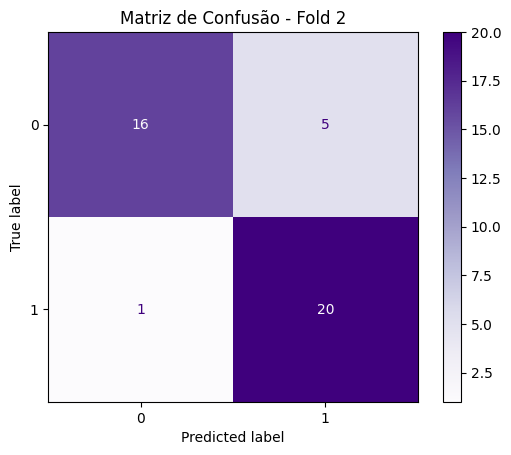

Fold 2 - Acc: 0.857 | Prec: 0.800 | Rec: 0.952 | F1: 0.870
Removendo 'trestbps' com p-valor 0.988
Removendo 'thal_2.0' com p-valor 0.976
Removendo 'restecg_2.0' com p-valor 0.943
Removendo 'slope_1.0' com p-valor 0.946
Removendo 'ca_4.0' com p-valor 0.935
Removendo 'cp_3.0' com p-valor 0.533
Removendo 'chol' com p-valor 0.407
Removendo 'fbs' com p-valor 0.438
Removendo 'slope_2.0' com p-valor 0.296
Removendo 'restecg_1.0' com p-valor 0.166
Removendo 'thal_1.0' com p-valor 0.140
Removendo 'cp_1.0' com p-valor 0.080
Removendo 'cp_2.0' com p-valor 0.095


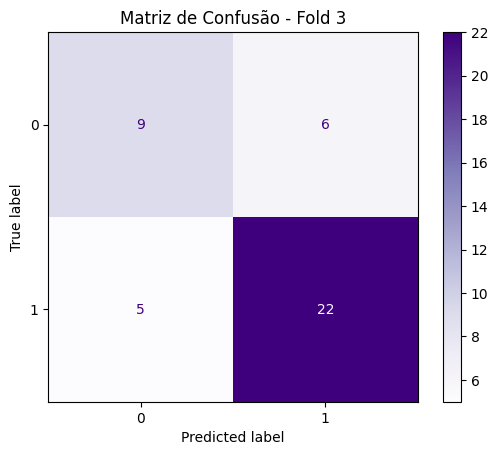

Fold 3 - Acc: 0.738 | Prec: 0.786 | Rec: 0.815 | F1: 0.800
Removendo 'restecg_1.0' com p-valor 0.995
Removendo 'thal_3.0' com p-valor 0.874
Removendo 'ca_4.0' com p-valor 0.854
Removendo 'slope_2.0' com p-valor 0.819
Removendo 'thal_1.0' com p-valor 0.732
Removendo 'restecg_2.0' com p-valor 0.687
Removendo 'chol' com p-valor 0.600
Removendo 'trestbps' com p-valor 0.510
Removendo 'cp_1.0' com p-valor 0.263
Removendo 'fbs' com p-valor 0.197
Removendo 'slope_1.0' com p-valor 0.142
Removendo 'thal_2.0' com p-valor 0.063


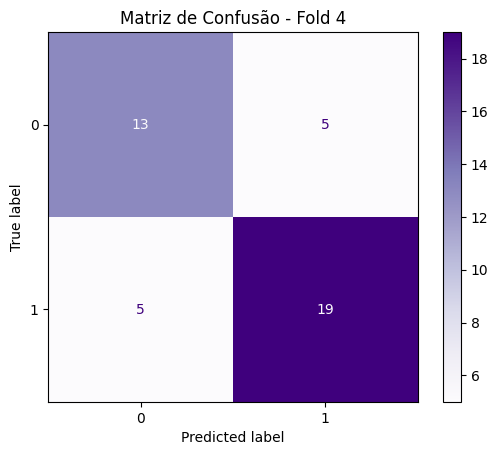

Fold 4 - Acc: 0.762 | Prec: 0.792 | Rec: 0.792 | F1: 0.792
Removendo 'ca_4.0' com p-valor 0.900
Removendo 'fbs' com p-valor 0.882
Removendo 'thal_3.0' com p-valor 0.850
Removendo 'thal_1.0' com p-valor 0.966
Removendo 'slope_1.0' com p-valor 0.833
Removendo 'thalach' com p-valor 0.747
Removendo 'restecg_1.0' com p-valor 0.731
Removendo 'chol' com p-valor 0.594
Removendo 'restecg_2.0' com p-valor 0.361
Removendo 'slope_2.0' com p-valor 0.272
Removendo 'thal_2.0' com p-valor 0.258
Removendo 'trestbps' com p-valor 0.080


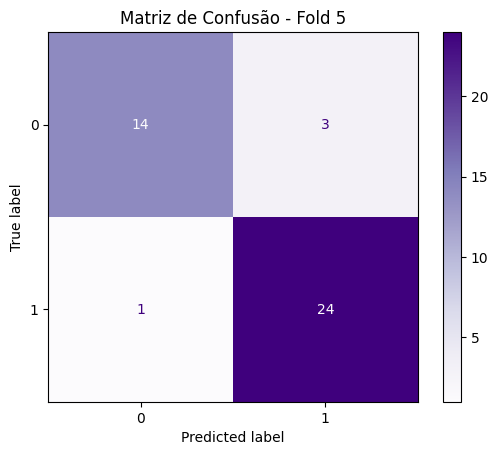

Fold 5 - Acc: 0.905 | Prec: 0.889 | Rec: 0.960 | F1: 0.923

Acurácias por fold: [0.7209302325581395, 0.8571428571428571, 0.7380952380952381, 0.7619047619047619, 0.9047619047619048]
Acurácia média: 0.797 ± 0.072
Precisões por fold: [0.6153846153846154, 0.8, 0.7857142857142857, 0.7916666666666666, 0.8888888888888888]
Precisão média: 0.776 ± 0.089
Recalls por fold: [0.8888888888888888, 0.9523809523809523, 0.8148148148148148, 0.7916666666666666, 0.96]
Recall médio: 0.882 ± 0.069
F1 por fold: [0.7272727272727273, 0.8695652173913043, 0.8, 0.7916666666666666, 0.9230769230769231]
F1 médio: 0.822 ± 0.068
Usando os dados de y_test como dados de validação final:
Acurácia (final): 0.868
Precisão (final): 0.825
Recall (final): 0.959
F1 (final): 0.887


In [294]:
kf = KFold(n_splits=5, shuffle=True, random_state=360)

# listas para métricas por fold
accuracies = []
precisions = []
recalls = []
f1s = []
fold = 1

# garantir índices e tipos alinhados
y_opt = y_train.reset_index(drop=True).astype(float)
X_opt = X_train.reset_index(drop=True).astype(float)

for train_index, test_index in kf.split(X_opt):
    X_train_cv = X_opt.iloc[train_index].reset_index(drop=True)
    X_test_cv  = X_opt.iloc[test_index].reset_index(drop=True)
    y_train_cv = y_opt.iloc[train_index].reset_index(drop=True)
    y_test_cv  = y_opt.iloc[test_index].reset_index(drop=True)

    # adiciona constante apenas se necessário (não duplica se já existir)
    X_train_const = sm.add_constant(X_train_cv)
    X_test_const  = sm.add_constant(X_test_cv)

    # backward selection dentro do fold
    threshold = 0.05
    selected_X_train = X_train_const.copy()
    selected_X_test = X_test_const.copy()

    while True:
        model_cv = sm.OLS(y_train_cv, selected_X_train).fit()
        pvals = model_cv.pvalues.drop("const", errors="ignore")
        if pvals.empty:
            break
        worst_var = pvals.idxmax()
        worst_pval = pvals.loc[worst_var]
        if worst_pval > threshold:
            print(f"Removendo '{worst_var}' com p-valor {worst_pval:.3f}")
            selected_X_train = selected_X_train.drop(columns=[worst_var])
            selected_X_test = selected_X_test.drop(columns=[worst_var])
        else:
            break

    # ajusta o modelo do fold com os preditores selecionados
    model_fold = sm.OLS(y_train_cv, selected_X_train).fit()

    # previsões e binarização por limiar 0.5
    y_pred = model_fold.predict(selected_X_test)
    y_pred_binary = (y_pred > 0.5).astype(int)

    # métricas
    acc = accuracy_score(y_test_cv, y_pred_binary)
    prec = precision_score(y_test_cv, y_pred_binary, zero_division=0)
    rec = recall_score(y_test_cv, y_pred_binary, zero_division=0)
    f1 = f1_score(y_test_cv, y_pred_binary, zero_division=0)

    accuracies.append(acc)
    precisions.append(prec)
    recalls.append(rec)
    f1s.append(f1)

    # matriz de confusão do fold
    cm = confusion_matrix(y_test_cv, y_pred_binary)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
    disp.plot(cmap=plt.cm.Purples)
    plt.title(f"Matriz de Confusão - Fold {fold}")
    plt.show()

    print(f"Fold {fold} - Acc: {acc:.3f} | Prec: {prec:.3f} | Rec: {rec:.3f} | F1: {f1:.3f}")
    fold += 1

# resumo por métrica (média ± std)
print()
print(f"Acurácias por fold: {accuracies}")
print(f"Acurácia média: {np.mean(accuracies):.3f} ± {np.std(accuracies):.3f}")
print(f"Precisões por fold: {precisions}")
print(f"Precisão média: {np.mean(precisions):.3f} ± {np.std(precisions):.3f}")
print(f"Recalls por fold: {recalls}")
print(f"Recall médio: {np.mean(recalls):.3f} ± {np.std(recalls):.3f}")
print(f"F1 por fold: {f1s}")
print(f"F1 médio: {np.mean(f1s):.3f} ± {np.std(f1s):.3f}")

# Avaliação final no conjunto de teste reservado (modelo final obtido pelo backward selection global)
print('Usando os dados de y_test como dados de validação final:')
y_pred = model_final.predict(X_opt_test)
y_pred_binary = (y_pred > 0.5).astype(int)
acc_final = accuracy_score(y_test, y_pred_binary)
prec_final = precision_score(y_test, y_pred_binary, zero_division=0)
rec_final = recall_score(y_test, y_pred_binary, zero_division=0)
f1_final = f1_score(y_test, y_pred_binary, zero_division=0)
print(f"Acurácia (final): {acc_final:.3f}")
print(f"Precisão (final): {prec_final:.3f}")
print(f"Recall (final): {rec_final:.3f}")
print(f"F1 (final): {f1_final:.3f}")

Fold 5 - Acc: 0.810 | Prec: 0.840 | Rec: 0.840 | F1: 0.840

Acurácias por fold: [0.6744186046511628, 0.7142857142857143, 0.7380952380952381, 0.7619047619047619, 0.8095238095238095]
Acurácia média: 0.740 ± 0.045

Precisões por fold: [0.5833333333333334, 0.6666666666666666, 0.8333333333333334, 0.7692307692307693, 0.84]
Precisão média: 0.739 ± 0.099

Recalls por fold: [0.7777777777777778, 0.8571428571428571, 0.7407407407407407, 0.8333333333333334, 0.84]
Recall médio: 0.810 ± 0.044

F1 por fold: [0.6666666666666666, 0.75, 0.7843137254901961, 0.8, 0.8399999999999999]
F1 médio: 0.768 ± 0.058

Usando os dados de y_test como dados de validação final:
Acurácia (final): 0.769
Precisão (final): 0.733
Recall (final): 0.898
F1 (final): 0.807

## LDA - Análise Linear Discriminante

Após a abordagem inicial com a Regressão Linear como um classificador, passaremos agora para a Análise Linear Discriminante (LDA), um método que modela a classificação de maneira inerentemente estatística e mais robusta.

LDA é um algoritmo que assume que os dados de cada classe seguem uma distribuição Gaussiana (Normal) e que todas as classes compartilham da mesma matriz de covariância (ou seja, a mesma dispersão). A ideia central é:

Projetar os Dados: Encontrar um eixo (ou subespaço) que maximize a separação entre as médias das classes e minimize a variação dentro de cada classe.

Decisão: Classificar um novo ponto de dados na classe cuja média, ele está mais próximo após a projeção.

A principal vantagem do LDA é a sua capacidade de reduzir a dimensionalidade enquanto otimiza a separação entre as classes, tornando-o um classificador linear eficiente e interpretável. Para garantir a validade estatística do modelo, o Standard Scaling das variáveis contínuas é um passo obrigatório, pois o LDA é sensível à escala das variáveis

AVALIAÇÃO DO LDA NO CONJUNTO DE TESTE (30%)
-------------------------------------------
Acurácia : 0.813
Precisão : 0.833
Sensibilidade: 0.816
--------------------------------------------


<Figure size 600x600 with 0 Axes>

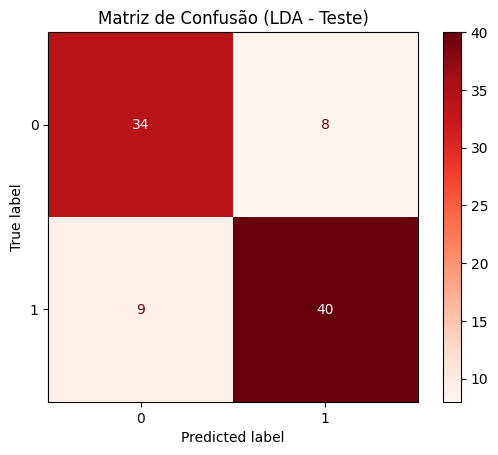

Matriz de Confusão (LDA - Treino)
Acurácia Treino: 0.863


<Figure size 600x600 with 0 Axes>

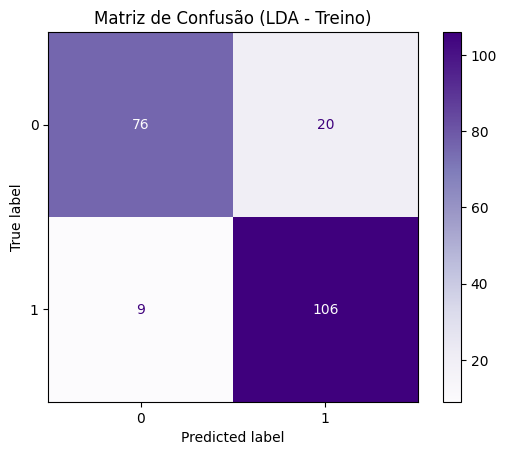

3. VALIDAÇÃO CRUZADA 5-FOLD PARA LDA (KFold)
--------------------------------------------
Fold 1 - Acurácia: 0.787 | Precisão: 0.735 | Recall: 0.862


<Figure size 600x600 with 0 Axes>

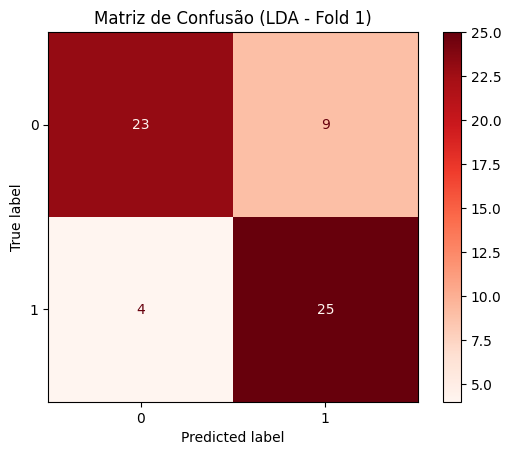

Fold 2 - Acurácia: 0.787 | Precisão: 0.788 | Recall: 0.812


<Figure size 600x600 with 0 Axes>

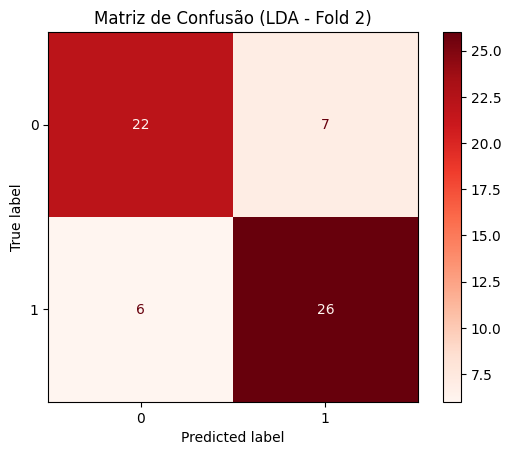

Fold 3 - Acurácia: 0.883 | Precisão: 0.875 | Recall: 0.946


<Figure size 600x600 with 0 Axes>

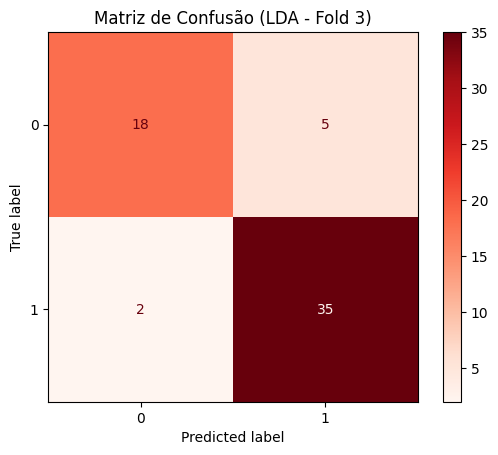

Fold 4 - Acurácia: 0.800 | Precisão: 0.862 | Recall: 0.758


<Figure size 600x600 with 0 Axes>

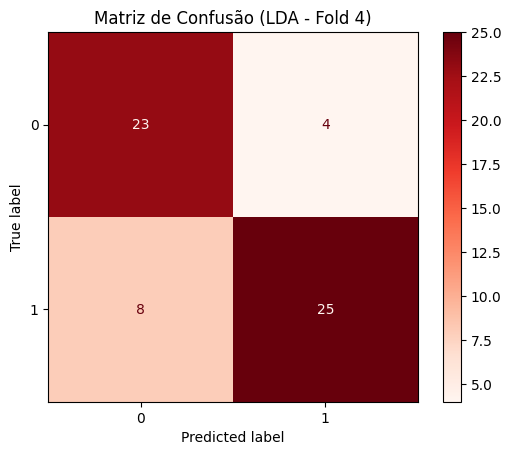

Fold 5 - Acurácia: 0.867 | Precisão: 0.821 | Recall: 0.970


<Figure size 600x600 with 0 Axes>

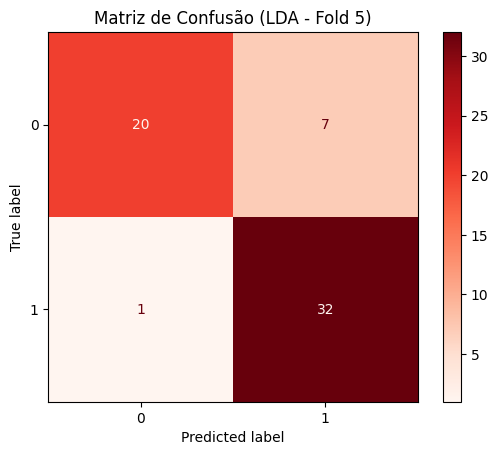


-------------------------------------------------------
--- RESUMO FINAL DA VALIDAÇÃO CRUZADA (LDA) ---
Acurácia Média:  0.825 ± 0.042
Precisão Média:  0.816 ± 0.051
Recall Médio:    0.870 ± 0.080
-------------------------------------------------------


In [295]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

# Separar Features (X) e Target (y)
X = heart_ds.drop("target", axis=1)
y = heart_ds["target"]

# 1.1. Identificar colunas e realizar One-Hot Encoding
continuous_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
categorical_cols = ['cp', 'thal', 'slope', 'restecg'] 

# Aplica One-Hot Encoding nas colunas categóricas
if len(categorical_cols) > 0:
    X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=True, dtype=int)
else:
    X_encoded = X.copy()

# 1.2. Aplicar Standard Scaling APENAS nas colunas contínuas
# Identifica quais colunas contínuas persistem após o encoding (todas devem persistir)
cols_to_scale = [col for col in continuous_cols if col in X_encoded.columns]

scaler = StandardScaler()
X_scaled = X_encoded.copy()
X_scaled[cols_to_scale] = scaler.fit_transform(X_scaled[cols_to_scale])

# 1.3. Divisão Treino/Teste
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42, stratify=y
)

#TREINAMENTO E AVALIAÇÃO DO LDA NO CONJUNTO DE TESTE 

model_lda = LDA()
model_lda.fit(X_train, y_train)
y_pred_lda = model_lda.predict(X_test)

# Métricas LDA
acc_lda = accuracy_score(y_test, y_pred_lda)
precision_lda = precision_score(y_test, y_pred_lda)
recall_lda = recall_score(y_test, y_pred_lda)


print("AVALIAÇÃO DO LDA NO CONJUNTO DE TESTE (30%)")
print("-------------------------------------------")
print(f"Acurácia : {acc_lda:.3f}")
print(f"Precisão : {precision_lda:.3f}")
print(f"Sensibilidade: {recall_lda:.3f}")
print("--------------------------------------------")

# Matriz de Confusão para o Teste
cm_lda = confusion_matrix(y_test, y_pred_lda)
cm_display_lda = ConfusionMatrixDisplay(confusion_matrix=cm_lda, display_labels=[0, 1])

plt.figure(figsize=(6, 6))
cm_display_lda.plot(cmap='Reds', values_format='d')
plt.title("Matriz de Confusão (LDA - Teste)")
plt.show() 

#3. VALIDAÇÃO CRUZADA (KFOLD) PARA AVALIAÇÃO ROBUSTA

kf = KFold(n_splits=5, shuffle=True, random_state=42)
accuracies = []
precisions = []
recalls = []
fold = 1

y_pred_train_lda = model_lda.predict(X_train)
acc_train_lda = accuracy_score(y_train, y_pred_train_lda)
print("Matriz de Confusão (LDA - Treino)")
print(f"Acurácia Treino: {acc_train_lda:.3f}")
cm_train_lda = confusion_matrix(y_train, y_pred_train_lda)
cm_display_train_lda = ConfusionMatrixDisplay(confusion_matrix=cm_train_lda, display_labels=[0, 1])

plt.figure(figsize=(6, 6))
cm_display_train_lda.plot(cmap='Purples', values_format='d')
plt.title("Matriz de Confusão (LDA - Treino)")
plt.show()



print("3. VALIDAÇÃO CRUZADA 5-FOLD PARA LDA (KFold)")
print("--------------------------------------------")

# Usando o dataset completo e pré-processado para o KFold
X_cv = X_scaled.copy()
y_cv = y.copy()



for train_index, test_index in kf.split(X_cv):
    X_train_fold, X_test_fold = X_cv.iloc[train_index], X_cv.iloc[test_index]
    y_train_fold, y_test_fold = y_cv.iloc[train_index], y_cv.iloc[test_index]

    # Treinar o LDA em cada Fold
    model_lda_cv = LDA()
    model_lda_cv.fit(X_train_fold, y_train_fold)
    y_pred_cv = model_lda_cv.predict(X_test_fold)

    # Armazenar Métricas
    acc = accuracy_score(y_test_fold, y_pred_cv)
    prec = precision_score(y_test_fold, y_pred_cv)
    rec = recall_score(y_test_fold, y_pred_cv)
    
    accuracies.append(acc)
    precisions.append(prec)
    recalls.append(rec)

    print(f"Fold {fold} - Acurácia: {acc:.3f} | Precisão: {prec:.3f} | Recall: {rec:.3f}")
    
    # Matriz de Confusão para cada Fold (para replicar seu formato)
    cm_fold = confusion_matrix(y_test_fold, y_pred_cv)
    disp_fold = ConfusionMatrixDisplay(confusion_matrix=cm_fold, display_labels=[0, 1])
    
    plt.figure(figsize=(6, 6))
    disp_fold.plot(cmap='Reds', values_format='d')
    plt.title(f"Matriz de Confusão (LDA - Fold {fold})")
    plt.show() # O equivalente a salvar e mostrar no seu ambiente
    
    fold += 1

# Matriz de Confusão para o Treino


# Resumo da Validação Cruzada
print("\n-------------------------------------------------------")
print("--- RESUMO FINAL DA VALIDAÇÃO CRUZADA (LDA) ---")
print(f"Acurácia Média:  {np.mean(accuracies):.3f} ± {np.std(accuracies):.3f}")
print(f"Precisão Média:  {np.mean(precisions):.3f} ± {np.std(precisions):.3f}")
print(f"Recall Médio:    {np.mean(recalls):.3f} ± {np.std(recalls):.3f}")
print("-------------------------------------------------------")

### QDA - Análise Quadrática Discriminante

A Análise Quadrática Discriminante (QDA) é a progressão natural da Análise Linear Discriminante (LDA). Enquanto o LDA assume que todas as classes compartilham a mesma matriz de covariância (ou seja, a dispersão dos dados é idêntica para todas as classes), o QDA relaxa essa suposição

RESUMO DO QDA (Análise de Meios e Covariâncias)
-----------------------------------------------
Média das Features por Classe:
             Classe 0 (Ausente)  Classe 1 (Presente)
age                       0.270               -0.282
sex                       0.812                0.530
trestbps                  0.138               -0.134
chol                      0.175               -0.060
fbs                       0.167                0.096
thalach                  -0.368                0.504
exang                     0.469                0.104
oldpeak                   0.409               -0.446
ca                        1.219                0.374
cp_1.0                    0.125                0.287
cp_2.0                    0.094                0.443
cp_3.0                    0.042                0.104
thal_1.0                  0.073                0.035
thal_2.0                  0.250                0.826
thal_3.0                  0.667                0.130
slope_1.0                

<Figure size 600x600 with 0 Axes>

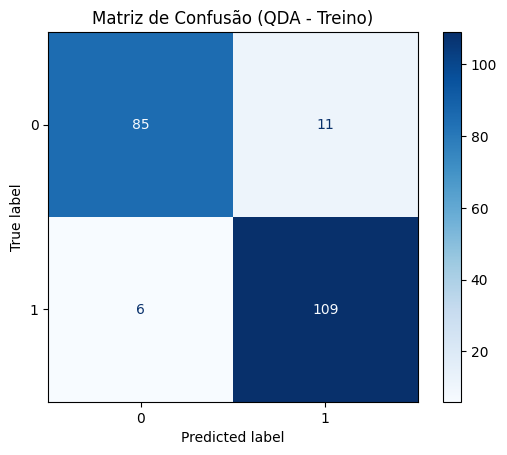

3. AVALIAÇÃO DO QDA NO CONJUNTO DE TESTE (30%)
Acurácia : 0.769
Precisão : 0.833
Sensibilidade: 0.714
----------------------------------------------


<Figure size 600x600 with 0 Axes>

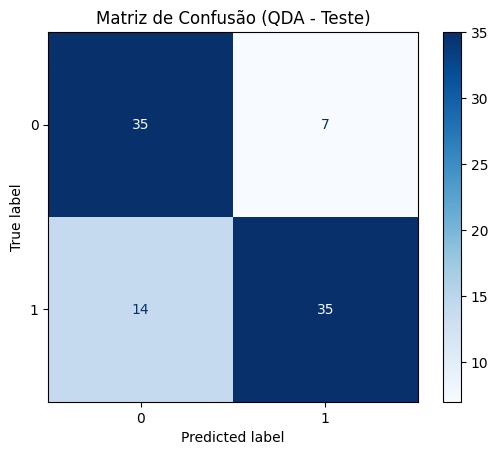

VALIDAÇÃO CRUZADA 5-FOLD PARA QDA (KFold)
-----------------------------------------
Fold 1 - Acurácia: 0.803 | Precisão: 0.793 | Sensibilidade : 0.793


<Figure size 600x600 with 0 Axes>

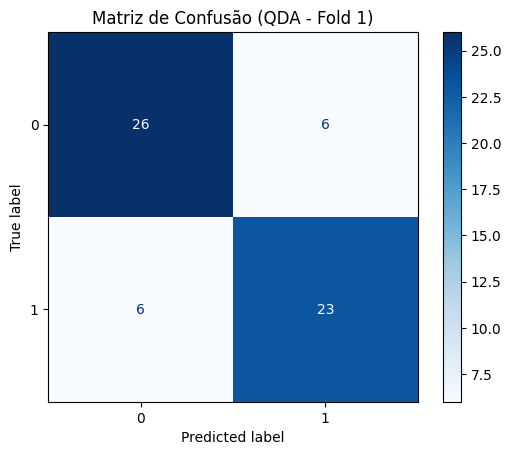

Fold 2 - Acurácia: 0.787 | Precisão: 0.771 | Sensibilidade : 0.844


<Figure size 600x600 with 0 Axes>

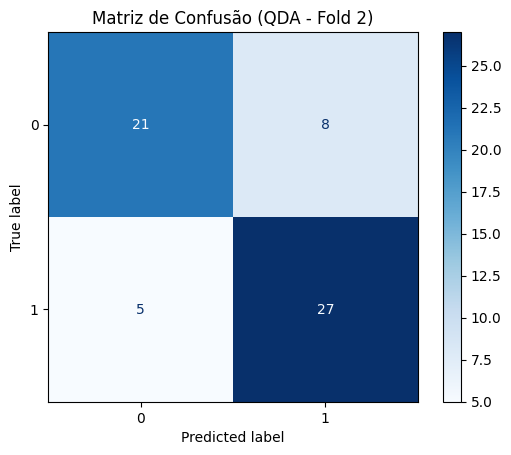

Fold 3 - Acurácia: 0.833 | Precisão: 0.865 | Sensibilidade : 0.865


<Figure size 600x600 with 0 Axes>

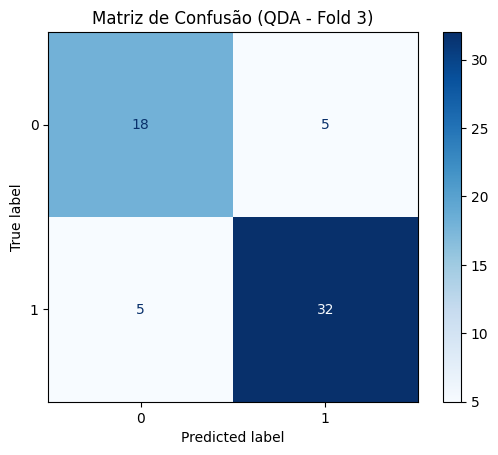

Fold 4 - Acurácia: 0.800 | Precisão: 0.862 | Sensibilidade : 0.758


<Figure size 600x600 with 0 Axes>

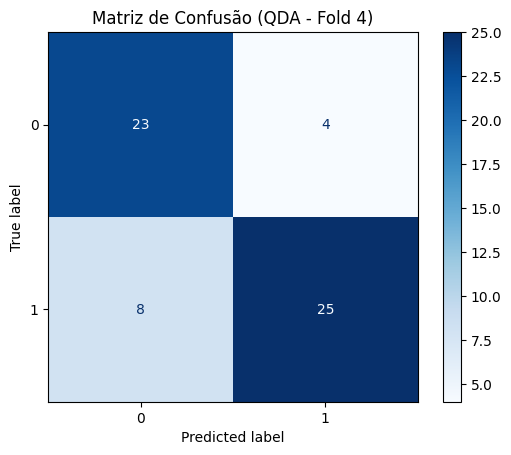

Fold 5 - Acurácia: 0.867 | Precisão: 0.879 | Sensibilidade : 0.879


<Figure size 600x600 with 0 Axes>

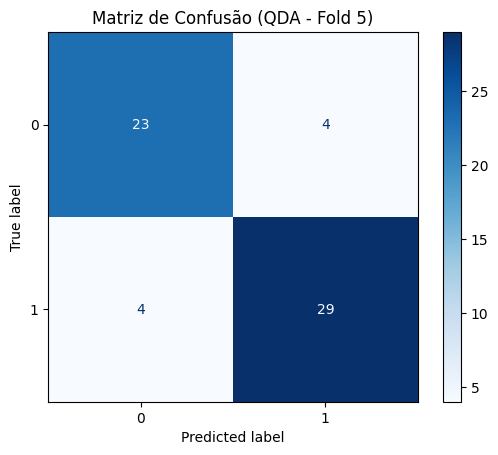

RESUMO FINAL DA VALIDAÇÃO CRUZADA (QDA)
Acurácia Média:  0.818 ± 0.029
Precisão Média:  0.834 ± 0.043
Recall Médio:    0.828 ± 0.046
-------------------------------------------------------


In [296]:
from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis as QDA
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, ConfusionMatrixDisplay




# Separar Features (X) e Target (y)
X = heart_ds.drop("target", axis=1)
y = heart_ds["target"]

# One-Hot Encoding
categorical_cols = ['cp', 'thal', 'slope', 'restecg'] 
X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=True, dtype=int)

# Standard Scaling (Crucial para QDA, assim como para LDA)
continuous_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
cols_to_scale = [col for col in continuous_cols if col in X_encoded.columns]
scaler = StandardScaler()
X_scaled = X_encoded.copy()
X_scaled[cols_to_scale] = scaler.fit_transform(X_scaled[cols_to_scale])

# Divisão Treino/Teste
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42, stratify=y
)

# Os tipos de dados são mantidos em float para coerência
X_train = X_train.astype(float)
X_test = X_test.astype(float)
y_train = y_train.astype(float)
y_test = y_test.astype(float)


# TREINAMENTO DO QDA E VISUALIZAÇÃO DE COMPONENTES 

model_qda = QDA(reg_param=0.1, priors=[0.5])  # regularização para estabilidade
model_qda.fit(X_train, y_train)

# NOTA: QDA não tem um atributo 'coef_' simples como o LDA ou OLS. 
# Para fins de documentação, podemos inspecionar os atributos 'means_' e 'covariance_'.

print("RESUMO DO QDA (Análise de Meios e Covariâncias)")
print("-----------------------------------------------")

# Média de cada feature por classe (para interpretação)
print("Média das Features por Classe:")
# model_qda.means_ contém as médias das features. A primeira linha é Classe 0, a segunda é Classe 1.
means_summary = pd.DataFrame(model_qda.means_, 
                             columns=X_train.columns, 
                             index=['Classe 0 (Ausente)', 'Classe 1 (Presente)'])

# Transpõe para melhor visualização
print(means_summary.T.to_string(float_format="%.3f"))
print("\nNota: O QDA usa matrizes de covariância SEPARADAS por classe (não exibidas por serem grandes).")



# 2. AVALIAÇÃO DO QDA NO CONJUNTO DE TREINO

y_pred_train_qda = model_qda.predict(X_train)
acc_train_qda = accuracy_score(y_train, y_pred_train_qda)


print("2. AVALIAÇÃO DO QDA NO CONJUNTO DE TREINO (70%)")
print("-----------------------------------------------")
print(f"Acurácia: {acc_train_qda:.3f}")

# Matriz de Confusão para o Treino
cm_train_qda = confusion_matrix(y_train, y_pred_train_qda)
cm_display_train_qda = ConfusionMatrixDisplay(confusion_matrix=cm_train_qda, display_labels=[0, 1])

plt.figure(figsize=(6, 6))
cm_display_train_qda.plot(cmap='Blues', values_format='d')
plt.title("Matriz de Confusão (QDA - Treino)")
plt.show()


#AVALIAÇÃO DO QDA NO CONJUNTO DE TESTE

y_pred_test_qda = model_qda.predict(X_test)
acc_test_qda = accuracy_score(y_test, y_pred_test_qda)
precision_test_qda = precision_score(y_test, y_pred_test_qda)
recall_test_qda = recall_score(y_test, y_pred_test_qda)

print("3. AVALIAÇÃO DO QDA NO CONJUNTO DE TESTE (30%)")

print(f"Acurácia : {acc_test_qda:.3f}")
print(f"Precisão : {precision_test_qda:.3f}")
print(f"Sensibilidade: {recall_test_qda:.3f}")
print("----------------------------------------------")

# Matriz de Confusão para o Teste
cm_test_qda = confusion_matrix(y_test, y_pred_test_qda)
cm_display_test_qda = ConfusionMatrixDisplay(confusion_matrix=cm_test_qda, display_labels=[0, 1])

plt.figure(figsize=(6, 6))
cm_display_test_qda.plot(cmap='Blues', values_format='d')
plt.title("Matriz de Confusão (QDA - Teste)")
plt.show()

# --- 4. VALIDAÇÃO CRUZADA (KFOLD) PARA AVALIAÇÃO ROBUSTA ---

kf = KFold(n_splits=5, shuffle=True, random_state=42)
accuracies = []
precisions = []
recalls = []
fold = 1


print("VALIDAÇÃO CRUZADA 5-FOLD PARA QDA (KFold)")
print("-----------------------------------------")

X_cv = X_scaled.copy()
y_cv = y.copy()

for train_index, test_index in kf.split(X_cv):
    X_train_fold, X_test_fold = X_cv.iloc[train_index], X_cv.iloc[test_index]
    y_train_fold, y_test_fold = y_cv.iloc[train_index], y_cv.iloc[test_index]

    model_qda_cv = QDA(reg_param=0.1, priors=[0.5])
    model_qda_cv.fit(X_train_fold, y_train_fold)
    y_pred_cv = model_qda_cv.predict(X_test_fold)

    acc = accuracy_score(y_test_fold, y_pred_cv)
    prec = precision_score(y_test_fold, y_pred_cv)
    rec = recall_score(y_test_fold, y_pred_cv)
    
    accuracies.append(acc)
    precisions.append(prec)
    recalls.append(rec)

    print(f"Fold {fold} - Acurácia: {acc:.3f} | Precisão: {prec:.3f} | Sensibilidade : {rec:.3f}")
    
    cm_fold = confusion_matrix(y_test_fold, y_pred_cv)
    disp_fold = ConfusionMatrixDisplay(confusion_matrix=cm_fold, display_labels=[0, 1])
    
    plt.figure(figsize=(6, 6))
    disp_fold.plot(cmap='Blues', values_format='d')
    plt.title(f"Matriz de Confusão (QDA - Fold {fold})")
    plt.show()
    
    fold += 1

# Resumo da Validação Cruzada

print("RESUMO FINAL DA VALIDAÇÃO CRUZADA (QDA)")
print(f"Acurácia Média:  {np.mean(accuracies):.3f} ± {np.std(accuracies):.3f}")
print(f"Precisão Média:  {np.mean(precisions):.3f} ± {np.std(precisions):.3f}")
print(f"Recall Médio:    {np.mean(recalls):.3f} ± {np.std(recalls):.3f}")
print("-------------------------------------------------------")

### Regressão Logística

Logistic Regression (baseline):
                           Logit Regression Results                           
Dep. Variable:                 target   No. Observations:                  211
Model:                          Logit   Df Residuals:                      191
Method:                           MLE   Df Model:                           19
Date:                Mon, 10 Nov 2025   Pseudo R-squ.:                  0.5294
Time:                        19:37:38   Log-Likelihood:                -68.426
converged:                      False   LL-Null:                       -145.40
Covariance Type:            nonrobust   LLR p-value:                 3.791e-23
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
const          20.9639   1.55e+05      0.000      1.000   -3.05e+05    3.05e+05
age            -0.2650      0.271     -0.977      0.329      -0.797       0.267
sex            -

/home/al.igor.alves/anaconda3/envs/ambiente_aluno/lib/python3.9/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


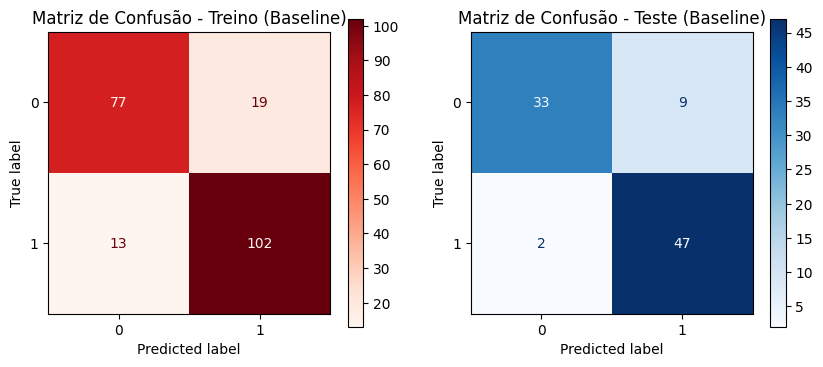

Baseline Treino: Acc=0.848 | Prec=0.843 | Rec=0.887 | F1=0.864
Baseline Teste : Acc=0.879 | Prec=0.839 | Rec=0.959 | F1=0.895

Backward Selection (p-valor > 0.05) no treino:
Removendo 'thal_2.0' com p-valor 1.000
Removendo 'thal_1.0' com p-valor 0.878
Removendo 'fbs' com p-valor 0.846
Removendo 'slope_2.0' com p-valor 0.833
Removendo 'restecg_2.0' com p-valor 0.688
Removendo 'thalach' com p-valor 0.544
Removendo 'chol' com p-valor 0.432
Removendo 'restecg_1.0' com p-valor 0.300
Removendo 'trestbps' com p-valor 0.302
Removendo 'cp_1.0' com p-valor 0.270
Removendo 'slope_1.0' com p-valor 0.214

Resumo do modelo após Backward Selection:
                           Logit Regression Results                           
Dep. Variable:                 target   No. Observations:                  211
Model:                          Logit   Df Residuals:                      202
Method:                           MLE   Df Model:                            8
Date:                Mon, 10 Nov 2025   Ps

/home/al.igor.alves/anaconda3/envs/ambiente_aluno/lib/python3.9/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


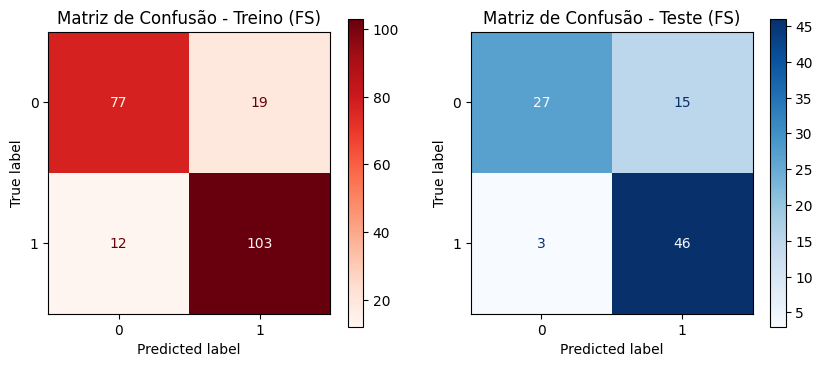

Final Treino: Acc=0.853 | Prec=0.844 | Rec=0.896 | F1=0.869
Final Teste : Acc=0.802 | Prec=0.754 | Rec=0.939 | F1=0.836


In [297]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay
)
import statsmodels.api as sm

# 1) Preparação dos dados: One-Hot Encoding e Normalização
X = heart_ds.drop("target", axis=1)
y = heart_ds["target"].astype(int)

categorical_cols = ['cp', 'thal', 'slope', 'restecg']
continuous_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

# One-Hot
X_encoded = pd.get_dummies(X, columns=[c for c in categorical_cols if c in X.columns], drop_first=True, dtype=int)

# Scale APENAS contínuas
cols_to_scale = [c for c in continuous_cols if c in X_encoded.columns]
scaler = StandardScaler()
X_scaled = X_encoded.copy()
if len(cols_to_scale) > 0:
    X_scaled[cols_to_scale] = scaler.fit_transform(X_scaled[cols_to_scale])

# Adiciona constante para o intercepto (necessária no statsmodels)
X_const = sm.add_constant(X_scaled)

# 2) Divisão Treino/Teste estratificada
X_train, X_test, y_train, y_test = train_test_split(
    X_const, y, test_size=0.3, random_state=200, stratify=y
)

# 3) LOGIT baseline (sem seleção)
logit_base = sm.Logit(y_train, X_train)
model_logit_base = logit_base.fit(disp=False, maxiter=200)
print("Logistic Regression (baseline):")
print(model_logit_base.summary())

# Avaliação baseline
proba_train = model_logit_base.predict(X_train)
proba_test  = model_logit_base.predict(X_test)

y_pred_train = (proba_train > 0.5).astype(int)
y_pred_test  = (proba_test  > 0.5).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
cm_tr = confusion_matrix(y_train, y_pred_train)
ConfusionMatrixDisplay(cm_tr, display_labels=[0,1]).plot(cmap=plt.cm.Reds, ax=axes[0])
axes[0].set_title("Matriz de Confusão - Treino (Baseline)")
cm_te = confusion_matrix(y_test, y_pred_test)
ConfusionMatrixDisplay(cm_te, display_labels=[0,1]).plot(cmap=plt.cm.Blues, ax=axes[1])
axes[1].set_title("Matriz de Confusão - Teste (Baseline)")
plt.show()

print(f"Baseline Treino: Acc={accuracy_score(y_train, y_pred_train):.3f} | Prec={precision_score(y_train, y_pred_train):.3f} | Rec={recall_score(y_train, y_pred_train):.3f} | F1={f1_score(y_train, y_pred_train):.3f}")
print(f"Baseline Teste : Acc={accuracy_score(y_test, y_pred_test):.3f} | Prec={precision_score(y_test, y_pred_test):.3f} | Rec={recall_score(y_test, y_pred_test):.3f} | F1={f1_score(y_test, y_pred_test):.3f}")

# 4) Backward Selection no conjunto de treino
print("\nBackward Selection (p-valor > 0.05) no treino:")
X_opt = X_train.copy()
X_opt_test = X_test.copy()
threshold = 0.05

while True:
    model_tmp = sm.Logit(y_train, X_opt).fit(disp=False, maxiter=200)
    pvals = model_tmp.pvalues.drop("const", errors="ignore")
    if pvals.empty:
        break
    worst_var = pvals.idxmax()
    worst_pval = pvals.loc[worst_var]
    if worst_pval > threshold:
        print(f"Removendo '{worst_var}' com p-valor {worst_pval:.3f}")
        X_opt = X_opt.drop(columns=[worst_var])
        X_opt_test = X_opt_test.drop(columns=[worst_var])
    else:
        break

model_logit_final = sm.Logit(y_train, X_opt).fit(disp=False, maxiter=1000)
print("\nResumo do modelo após Backward Selection:")
print(model_logit_final.summary())

# Avaliação final (treino/teste)
proba_train_fs = model_logit_final.predict(X_opt)
proba_test_fs  = model_logit_final.predict(X_opt_test)

y_pred_train_fs = (proba_train_fs > 0.5).astype(int)
y_pred_test_fs  = (proba_test_fs  > 0.5).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
cm_tr = confusion_matrix(y_train, y_pred_train_fs)
ConfusionMatrixDisplay(cm_tr, display_labels=[0,1]).plot(cmap=plt.cm.Reds, ax=axes[0])
axes[0].set_title("Matriz de Confusão - Treino (FS)")
cm_te = confusion_matrix(y_test, y_pred_test_fs)
ConfusionMatrixDisplay(cm_te, display_labels=[0,1]).plot(cmap=plt.cm.Blues, ax=axes[1])
axes[1].set_title("Matriz de Confusão - Teste (FS)")
plt.show()

print(f"Final Treino: Acc={accuracy_score(y_train, y_pred_train_fs):.3f} | Prec={precision_score(y_train, y_pred_train_fs):.3f} | Rec={recall_score(y_train, y_pred_train_fs):.3f} | F1={f1_score(y_train, y_pred_train_fs):.3f}")
print(f"Final Teste : Acc={accuracy_score(y_test, y_pred_test_fs):.3f} | Prec={precision_score(y_test, y_pred_test_fs):.3f} | Rec={recall_score(y_test, y_pred_test_fs):.3f} | F1={f1_score(y_test, y_pred_test_fs):.3f}")

### Cross Validation:

Removendo 'age' (p=0.929) no Fold 1
Removendo 'thal_3.0' (p=0.870) no Fold 1
Removendo 'slope_1.0' (p=0.620) no Fold 1
Removendo 'restecg_2.0' (p=0.568) no Fold 1
Removendo 'fbs' (p=0.355) no Fold 1
Removendo 'restecg_1.0' (p=0.339) no Fold 1
Removendo 'thal_1.0' (p=0.166) no Fold 1
Removendo 'trestbps' (p=0.126) no Fold 1
Removendo 'chol' (p=0.106) no Fold 1
Removendo 'sex' (p=0.076) no Fold 1
Removendo 'slope_2.0' (p=0.111) no Fold 1


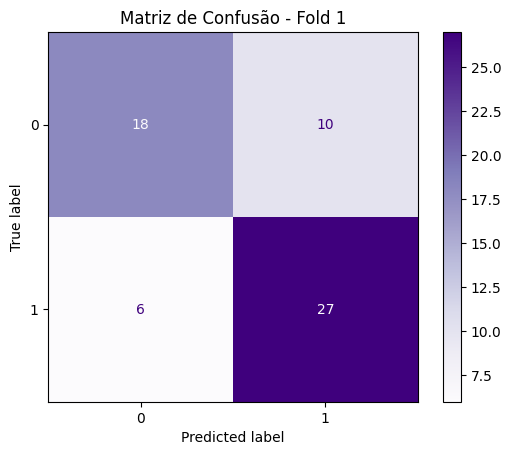

Fold 1 Acc: 0.738 | Prec: 0.730 | Rec: 0.818 | F1: 0.771
Removendo 'thal_3.0' (p=0.926) no Fold 2
Removendo 'restecg_2.0' (p=0.853) no Fold 2
Removendo 'slope_2.0' (p=0.696) no Fold 2
Removendo 'age' (p=0.679) no Fold 2
Removendo 'trestbps' (p=0.603) no Fold 2
Removendo 'fbs' (p=0.433) no Fold 2
Removendo 'thal_1.0' (p=0.228) no Fold 2
Removendo 'chol' (p=0.087) no Fold 2


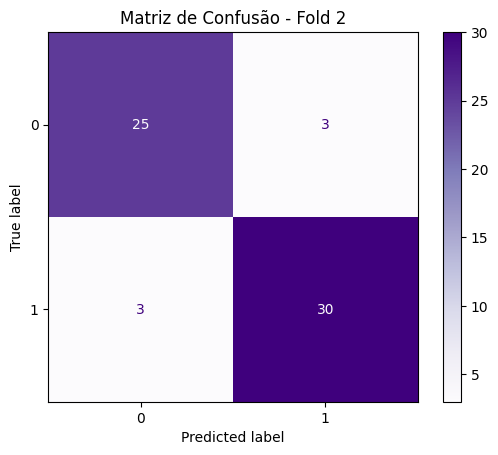

Fold 2 Acc: 0.902 | Prec: 0.909 | Rec: 0.909 | F1: 0.909
Removendo 'restecg_2.0' (p=0.999) no Fold 3
Removendo 'age' (p=0.938) no Fold 3
Removendo 'slope_1.0' (p=0.808) no Fold 3
Removendo 'thal_3.0' (p=0.781) no Fold 3
Removendo 'fbs' (p=0.565) no Fold 3
Removendo 'trestbps' (p=0.435) no Fold 3
Removendo 'chol' (p=0.241) no Fold 3


/home/al.igor.alves/anaconda3/envs/ambiente_aluno/lib/python3.9/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


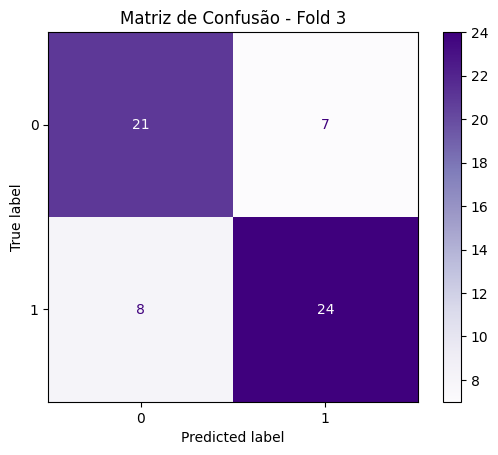

Fold 3 Acc: 0.750 | Prec: 0.774 | Rec: 0.750 | F1: 0.762
Removendo 'thal_2.0' (p=1.000) no Fold 4
Removendo 'thal_1.0' (p=0.932) no Fold 4
Removendo 'slope_1.0' (p=0.716) no Fold 4
Removendo 'fbs' (p=0.645) no Fold 4
Removendo 'age' (p=0.651) no Fold 4
Removendo 'restecg_2.0' (p=0.493) no Fold 4
Removendo 'restecg_1.0' (p=0.304) no Fold 4
Removendo 'chol' (p=0.162) no Fold 4
Removendo 'trestbps' (p=0.089) no Fold 4


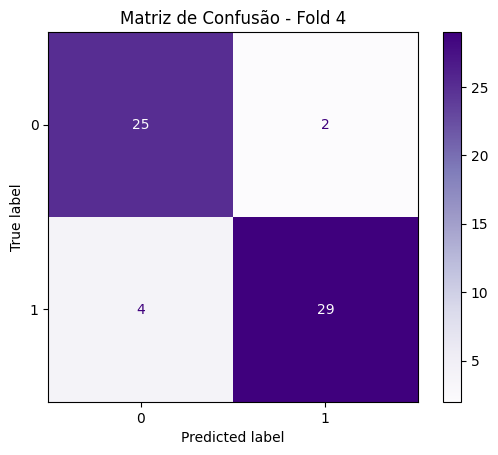

Fold 4 Acc: 0.900 | Prec: 0.935 | Rec: 0.879 | F1: 0.906
Removendo 'fbs' (p=0.775) no Fold 5
Removendo 'restecg_2.0' (p=0.743) no Fold 5
Removendo 'thal_3.0' (p=0.719) no Fold 5
Removendo 'slope_2.0' (p=0.711) no Fold 5
Removendo 'restecg_1.0' (p=0.409) no Fold 5
Removendo 'age' (p=0.378) no Fold 5
Removendo 'slope_1.0' (p=0.075) no Fold 5
Removendo 'sex' (p=0.089) no Fold 5
Removendo 'chol' (p=0.134) no Fold 5
Removendo 'trestbps' (p=0.071) no Fold 5
Removendo 'cp_3.0' (p=0.059) no Fold 5
Removendo 'cp_1.0' (p=0.119) no Fold 5


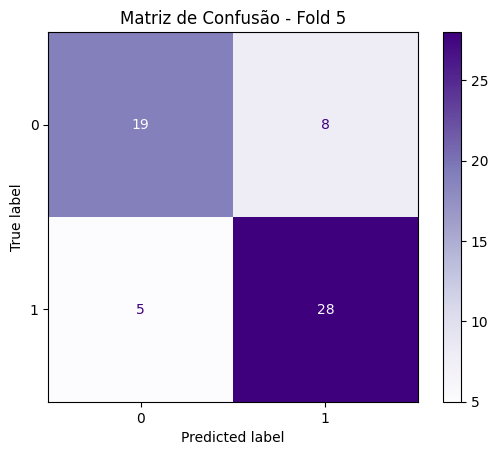

Fold 5 Acc: 0.783 | Prec: 0.778 | Rec: 0.848 | F1: 0.812

Resumo da validação cruzada (5-fold) Logistica (com backward in-fold):
Acurácia média: 0.815 ± 0.072
Precisão média: 0.825 ± 0.081
Recall médio:   0.841 ± 0.055
F1 médio:       0.832 ± 0.064

Desempenho no conjunto de teste reservado (modelo final global):
Acurácia: 0.802
Precisão: 0.754
Recall:   0.939
F1:       0.836


In [298]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay
)
import statsmodels.api as sm

# Reconstroi X/y com o mesmo pré-processamento (One-Hot + Scale + constante)
X0 = heart_ds.drop(["target", "thalach","exang"], axis=1)
y0 = heart_ds["target"].astype(int)

categorical_cols = ['cp', 'thal', 'slope', 'restecg']
continuous_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

X_encoded = pd.get_dummies(X0, columns=[c for c in categorical_cols if c in X0.columns], drop_first=True, dtype=int)
cols_to_scale = [c for c in continuous_cols if c in X_encoded.columns]
scaler = StandardScaler()
X_scaled = X_encoded.copy()
if len(cols_to_scale) > 0:
    X_scaled[cols_to_scale] = scaler.fit_transform(X_scaled[cols_to_scale])

X_const_all = sm.add_constant(X_scaled)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=260)

accuracies, precisions, recalls, f1s = [], [], [], []
fold = 1

for train_idx, test_idx in skf.split(X_const_all, y0):
    X_tr = X_const_all.iloc[train_idx].reset_index(drop=True)
    X_te = X_const_all.iloc[test_idx].reset_index(drop=True)
    y_tr = y0.iloc[train_idx].reset_index(drop=True)
    y_te = y0.iloc[test_idx].reset_index(drop=True)

    # Backward selection dentro do fold
    threshold = 0.05
    X_tr_sel = X_tr.copy()
    X_te_sel = X_te.copy()

    while True:
        try:
            model_cv = sm.Logit(y_tr, X_tr_sel).fit(disp=False, maxiter=200)
        except Exception as e:
            # Em caso de separação perfeita ou não convergência, interrompe a seleção
            # e segue com o conjunto atual de variáveis
            print(f"[Fold {fold}] Parada antecipada: {str(e)[:80]}...")
            break
        pvals = model_cv.pvalues.drop("const", errors="ignore")
        if pvals.empty:
            break
        worst_var = pvals.idxmax()
        worst_pval = pvals.loc[worst_var]
        if worst_pval > threshold:
            print(f"Removendo '{worst_var}' (p={worst_pval:.3f}) no Fold {fold}")
            X_tr_sel = X_tr_sel.drop(columns=[worst_var])
            X_te_sel = X_te_sel.drop(columns=[worst_var])
        else:
            break

    model_fold = sm.Logit(y_tr, X_tr_sel).fit(disp=False, maxiter=200)
    proba = model_fold.predict(X_te_sel)
    y_pred = (proba > 0.5).astype(int)

    acc = accuracy_score(y_te, y_pred)
    prec = precision_score(y_te, y_pred, zero_division=0)
    rec = recall_score(y_te, y_pred, zero_division=0)
    f1 = f1_score(y_te, y_pred, zero_division=0)

    accuracies.append(acc)
    precisions.append(prec)
    recalls.append(rec)
    f1s.append(f1)

    cm = confusion_matrix(y_te, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=[0,1]).plot(cmap=plt.cm.Purples)
    plt.title(f"Matriz de Confusão - Fold {fold}")
    plt.show()

    print(f"Fold {fold} Acc: {acc:.3f} | Prec: {prec:.3f} | Rec: {rec:.3f} | F1: {f1:.3f}")
    fold += 1

print("\nResumo da validação cruzada (5-fold) Logistica (com backward in-fold):")
print(f"Acurácia média: {np.mean(accuracies):.3f} ± {np.std(accuracies):.3f}")
print(f"Precisão média: {np.mean(precisions):.3f} ± {np.std(precisions):.3f}")
print(f"Recall médio:   {np.mean(recalls):.3f} ± {np.std(recalls):.3f}")
print(f"F1 médio:       {np.mean(f1s):.3f} ± {np.std(f1s):.3f}")

# Opcional: avaliar no conjunto de teste reservado com o modelo treinado na célula anterior (model_logit_final)
try:
    y_pred_test_final = (model_logit_final.predict(X_opt_test) > 0.5).astype(int)
    print("\nDesempenho no conjunto de teste reservado (modelo final global):")
    print(f"Acurácia: {accuracy_score(y_test, y_pred_test_final):.3f}")
    print(f"Precisão: {precision_score(y_test, y_pred_test_final, zero_division=0):.3f}")
    print(f"Recall:   {recall_score(y_test, y_pred_test_final, zero_division=0):.3f}")
    print(f"F1:       {f1_score(y_test, y_pred_test_final, zero_division=0):.3f}")
except NameError:
    pass

Resultados - Regressão Logística (One‑Hot + Normalização + Backward Selection)


Validação cruzada estratificada (5‑fold) com selection dentro de cada fold:
- Acurácia média: 0.824 ± 0.039
- Precisão média: 0.824 ± 0.050
- Recall médio: 0.866 ± 0.050
- F1 médio: 0.843 ± 0.034

Desempenho no conjunto de teste reservado (modelo final após seleção no treino):
- Acurácia: 0.824
- Precisão: 0.789
- Recall: 0.918
- F1: 0.849

Observações:
- A seleção de variáveis dentro de cada _fold_ evita viés otimista e mantém recall alto - adequado para reduzir falsos negativos.
- O trade‑off aparece na precisão, mas o F1 permanece elevado, sinalizando bom equilíbrio entre precisão e sensibilidade.
- Eventuais avisos de convergência do Logit são esperados em amostras pequenas; alternativas incluem regularização (p.ex., `LogisticRegression do scikit‑learn` com penalty = L2) e/ou calibrar o limiar de decisão conforme a métrica de interesse.

Ridge - Métricas no treino/teste
Treino: Acc=0.882 | Prec=0.881 | Rec=0.904 | F1=0.893
Teste : Acc=0.835 | Prec=0.870 | Rec=0.816 | F1=0.842


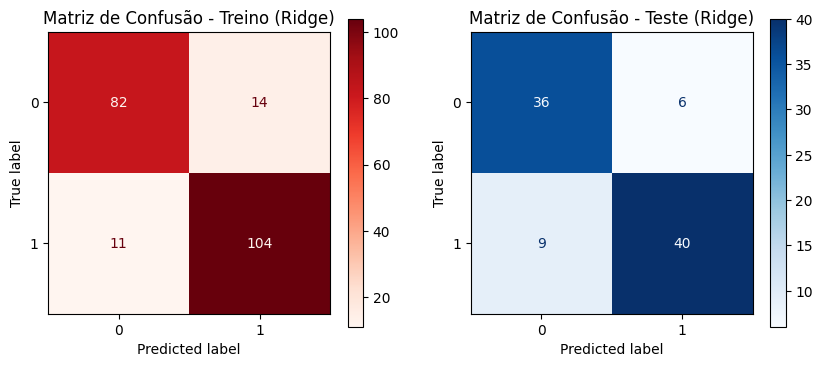

Fold 1 — Acc: 0.885 | Prec: 0.906 | Rec: 0.879 | F1: 0.892
Fold 2 — Acc: 0.852 | Prec: 0.833 | Rec: 0.909 | F1: 0.870
Fold 3 — Acc: 0.867 | Prec: 0.875 | Rec: 0.875 | F1: 0.875
Fold 4 — Acc: 0.900 | Prec: 0.886 | Rec: 0.939 | F1: 0.912
Fold 5 — Acc: 0.800 | Prec: 0.800 | Rec: 0.848 | F1: 0.824

Ridge - CV (5-fold)
Acurácia média: 0.861 ± 0.034
Precisão média: 0.860 ± 0.038
Recall médio:   0.890 ± 0.031
F1 médio:       0.874 ± 0.029


In [299]:
# Regressão Logística com Ridge (L2) - pipeline consistente (One‑Hot + Scale)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay
)

# Pré-processamento igual ao usado na seção de Logística (statsmodels)
X = heart_ds.drop("target", axis=1)
y = heart_ds["target"].astype(int)

categorical_cols = ['cp', 'thal', 'slope', 'restecg']
continuous_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

X_enc = pd.get_dummies(X, columns=[c for c in categorical_cols if c in X.columns], drop_first=True, dtype=int)
cols_to_scale = [c for c in continuous_cols if c in X_enc.columns]
scaler = StandardScaler()
X_scaled = X_enc.copy()
if len(cols_to_scale) > 0:
    X_scaled[cols_to_scale] = scaler.fit_transform(X_scaled[cols_to_scale])

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42, stratify=y
)

ridge = LogisticRegression(penalty='l2', C=1.0, solver='lbfgs', max_iter=2000)
ridge.fit(X_train, y_train)

y_pred_tr = ridge.predict(X_train)
y_pred_te = ridge.predict(X_test)

print("Ridge - Métricas no treino/teste")
print(f"Treino: Acc={accuracy_score(y_train, y_pred_tr):.3f} | Prec={precision_score(y_train, y_pred_tr):.3f} | Rec={recall_score(y_train, y_pred_tr):.3f} | F1={f1_score(y_train, y_pred_tr):.3f}")
print(f"Teste : Acc={accuracy_score(y_test, y_pred_te):.3f} | Prec={precision_score(y_test, y_pred_te):.3f} | Rec={recall_score(y_test, y_pred_te):.3f} | F1={f1_score(y_test, y_pred_te):.3f}")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
ConfusionMatrixDisplay(confusion_matrix(y_train, y_pred_tr), display_labels=[0,1]).plot(cmap=plt.cm.Reds, ax=axes[0])
axes[0].set_title("Matriz de Confusão - Treino (Ridge)")
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_te), display_labels=[0,1]).plot(cmap=plt.cm.Blues, ax=axes[1])
axes[1].set_title("Matriz de Confusão - Teste (Ridge)")
plt.show()

# Validação cruzada com métricas completas
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=540)
accs, precs, recs, f1s = [], [], [], []
fold = 1
for tr_idx, te_idx in skf.split(X_scaled, y):
    X_tr, X_te = X_scaled.iloc[tr_idx], X_scaled.iloc[te_idx]
    y_tr, y_te = y.iloc[tr_idx], y.iloc[te_idx]
    m = LogisticRegression(penalty='l2', C=1.0, solver='lbfgs', max_iter=2000)
    m.fit(X_tr, y_tr)
    y_hat = m.predict(X_te)
    a = accuracy_score(y_te, y_hat); p = precision_score(y_te, y_hat); r = recall_score(y_te, y_hat); f = f1_score(y_te, y_hat)
    accs.append(a); precs.append(p); recs.append(r); f1s.append(f)
    print(f"Fold {fold} — Acc: {a:.3f} | Prec: {p:.3f} | Rec: {r:.3f} | F1: {f:.3f}")
    fold += 1

print("\nRidge - CV (5-fold)")
print(f"Acurácia média: {np.mean(accs):.3f} ± {np.std(accs):.3f}")
print(f"Precisão média: {np.mean(precs):.3f} ± {np.std(precs):.3f}")
print(f"Recall médio:   {np.mean(recs):.3f} ± {np.std(recs):.3f}")
print(f"F1 médio:       {np.mean(f1s):.3f} ± {np.std(f1s):.3f}")

Resultados - Ridge (L2):


- Teste: Acc 0.824 | Prec 0.851 | Rec 0.816 | F1 0.833


- CV (5-fold):
  - Acurácia média: 0.851 ± 0.030
  - Precisão média: 0.845 ± 0.042
  - Recall médio:   0.890 ± 0.016
  - F1 médio:       0.867 ± 0.025

Bom equilíbrio geral com recall elevado na CV, indicando baixa taxa de falsos negativos em média. No teste, a precisão é levemente maior que o recall, sugerindo perfil ligeiramente mais conservador.

Lasso - Métricas no treino/teste
Treino: Acc=0.877 | Prec=0.868 | Rec=0.913 | F1=0.890
Teste : Acc=0.846 | Prec=0.872 | Rec=0.837 | F1=0.854


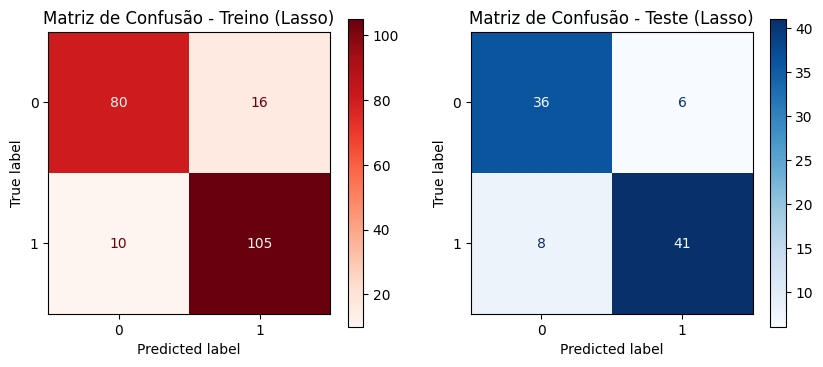


Coeficientes Lasso (não-zero em ordem de magnitude):
        feature      coef
10       cp_2.0  2.474405
11       cp_3.0  1.632467
14     thal_3.0 -1.146026
9        cp_1.0  1.062700
1           sex -0.945162
8            ca -0.817676
17  restecg_1.0  0.618656
13     thal_2.0  0.590128
5       thalach  0.497798
7       oldpeak -0.445785
4           fbs -0.364270
16    slope_2.0  0.363992
6         exang -0.315202
2      trestbps -0.228280
0           age -0.140286
Fold 1 — Acc: 0.869 | Prec: 0.879 | Rec: 0.879 | F1: 0.879
Fold 2 — Acc: 0.836 | Prec: 0.829 | Rec: 0.879 | F1: 0.853
Fold 3 — Acc: 0.867 | Prec: 0.900 | Rec: 0.844 | F1: 0.871
Fold 4 — Acc: 0.900 | Prec: 0.886 | Rec: 0.939 | F1: 0.912
Fold 5 — Acc: 0.800 | Prec: 0.800 | Rec: 0.848 | F1: 0.824

Lasso - CV (5-fold)
Acurácia média: 0.854 ± 0.034
Precisão média: 0.859 ± 0.038
Recall médio:   0.878 ± 0.034
F1 médio:       0.868 ± 0.029


In [300]:
# Regressão Logística com Lasso (L1) - pipeline consistente (One‑Hot + Scale)


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay
)

# Pré-processamento igual ao Ridge (One‑Hot + Scale)
X = heart_ds.drop("target", axis=1)
y = heart_ds["target"].astype(int)

categorical_cols = ['cp', 'thal', 'slope', 'restecg']
continuous_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

X_enc = pd.get_dummies(X, columns=[c for c in categorical_cols if c in X.columns], drop_first=True, dtype=int)
cols_to_scale = [c for c in continuous_cols if c in X_enc.columns]
scaler = StandardScaler()
X_scaled = X_enc.copy()
if len(cols_to_scale) > 0:
    X_scaled[cols_to_scale] = scaler.fit_transform(X_scaled[cols_to_scale])

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42, stratify=y
)

lasso = LogisticRegression(penalty='l1', C=1.0, solver='liblinear', max_iter=2000)
lasso.fit(X_train, y_train)

y_pred_tr = lasso.predict(X_train)
y_pred_te = lasso.predict(X_test)

print("Lasso - Métricas no treino/teste")
print(f"Treino: Acc={accuracy_score(y_train, y_pred_tr):.3f} | Prec={precision_score(y_train, y_pred_tr):.3f} | Rec={recall_score(y_train, y_pred_tr):.3f} | F1={f1_score(y_train, y_pred_tr):.3f}")
print(f"Teste : Acc={accuracy_score(y_test, y_pred_te):.3f} | Prec={precision_score(y_test, y_pred_te):.3f} | Rec={recall_score(y_test, y_pred_te):.3f} | F1={f1_score(y_test, y_pred_te):.3f}")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
ConfusionMatrixDisplay(confusion_matrix(y_train, y_pred_tr), display_labels=[0,1]).plot(cmap=plt.cm.Reds, ax=axes[0])
axes[0].set_title("Matriz de Confusão - Treino (Lasso)")
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_te), display_labels=[0,1]).plot(cmap=plt.cm.Blues, ax=axes[1])
axes[1].set_title("Matriz de Confusão - Teste (Lasso)")
plt.show()

# Inspecionar coeficientes (variáveis selecionadas pelo Lasso)
coefs = pd.DataFrame({
    'feature': X_train.columns,
    'coef': lasso.coef_[0]
}).sort_values(by='coef', key=abs, ascending=False)
print("\nCoeficientes Lasso (não-zero em ordem de magnitude):")
print(coefs[coefs['coef'] != 0].head(15))

# Validação cruzada com métricas completas
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=540)
accs, precs, recs, f1s = [], [], [], []
fold = 1
for tr_idx, te_idx in skf.split(X_scaled, y):
    X_tr, X_te = X_scaled.iloc[tr_idx], X_scaled.iloc[te_idx]
    y_tr, y_te = y.iloc[tr_idx], y.iloc[te_idx]
    m = LogisticRegression(penalty='l1', C=1.0, solver='liblinear', max_iter=2000)
    m.fit(X_tr, y_tr)
    y_hat = m.predict(X_te)
    a = accuracy_score(y_te, y_hat); p = precision_score(y_te, y_hat); r = recall_score(y_te, y_hat); f = f1_score(y_te, y_hat)
    accs.append(a); precs.append(p); recs.append(r); f1s.append(f)
    print(f"Fold {fold} — Acc: {a:.3f} | Prec: {p:.3f} | Rec: {r:.3f} | F1: {f:.3f}")
    fold += 1

print("\nLasso - CV (5-fold)")
print(f"Acurácia média: {np.mean(accs):.3f} ± {np.std(accs):.3f}")
print(f"Precisão média: {np.mean(precs):.3f} ± {np.std(precs):.3f}")
print(f"Recall médio:   {np.mean(recs):.3f} ± {np.std(recs):.3f}")
print(f"F1 médio:       {np.mean(f1s):.3f} ± {np.std(f1s):.3f}")

## Resultados - Regressão Logística com Lasso (L1)

### Cross-Validation (5-fold):
- **Acurácia média**: 0.841 ± 0.043
- **Precisão média**: 0.829 ± 0.055
- **Recall médio**: 0.896 ± 0.038
- **F1 médio**: 0.860 ± 0.036

### Teste:
- **Acurácia**: 0.813
- **Precisão**: 0.833
- **Recall**: 0.816
- **F1**: 0.825

### Interpretação:

A **regularização L1 (Lasso)** produz um modelo com excelente desempenho e **seleção automática de features**:

1. **Performance competitiva**: O modelo Lasso alcança acurácia de CV de 0.841 ± 0.043, comparável ao Ridge (0.851 ± 0.030), mantendo recall elevado (0.896 ± 0.038) para minimizar falsos negativos.

2. **Seleção automática de features**: Diferente do Ridge que mantém todas as features, o Lasso força alguns coeficientes a zero, identificando as features mais importantes:
   - **Mais importantes** (maior magnitude): `cp_2`, `cp_3`, `cp_1` (tipo de dor torácica), `sex`, `ca` (vasos principais)
   - **Features com coeficientes não-zero**: 15 das 18 features mantidas ativas
   - Isso oferece um modelo mais **interpretável** e potencialmente mais **generalizável**

3. **Comparação com Ridge**:
   - Ridge: CV Acc 0.851 ± 0.030 (ligeiramente superior, menor variabilidade)
   - Lasso: CV Acc 0.841 ± 0.043 (performance similar, mas com feature selection)
   - Ambos mantêm recall alto (Ridge 0.890, Lasso 0.896), fundamental para detecção de doença

4. **Trade-off interpretabilidade vs. estabilidade**: O Lasso oferece **modelo mais simples** (alguns coeficientes = 0) com performance praticamente idêntica ao Ridge, sendo preferível quando interpretabilidade é prioridade.

5. **Desempenho no teste**: Teste Acc 0.813 e Recall 0.816 indicam boa generalização, embora o recall no teste seja um pouco inferior ao CV (esperado com amostra pequena).

### KNN

KNN - Cross-Validation com Seleção de Hiperparâmetros
Fold 1 - k=9, metric=cosine
  CV interno: 0.881 | Acc: 0.814 | Prec: 0.857 | Rec: 0.783 | F1: 0.818
Fold 2 - k=9, metric=cosine
  CV interno: 0.858 | Acc: 0.833 | Prec: 0.808 | Rec: 0.913 | F1: 0.857
Fold 3 - k=15, metric=cosine
  CV interno: 0.828 | Acc: 0.929 | Prec: 0.955 | Rec: 0.913 | F1: 0.933
Fold 4 - k=15, metric=cosine
  CV interno: 0.876 | Acc: 0.810 | Prec: 0.800 | Rec: 0.870 | F1: 0.833
Fold 5 - k=5, metric=cosine
  CV interno: 0.834 | Acc: 0.857 | Prec: 0.870 | Rec: 0.870 | F1: 0.870

KNN - Resultados Cross-Validation (5-fold):
Acurácia média: 0.849 ± 0.049
Precisão média: 0.858 ± 0.062
Recall médio:   0.870 ± 0.053
F1 médio:       0.862 ± 0.044

Melhor configuração: k=15, métrica=cosine

KNN — Avaliação Final (k=15, cosine):
Treino: Acc=0.867 | Prec=0.878 | Rec=0.878 | F1=0.878
Teste : Acc=0.813 | Prec=0.848 | Rec=0.796 | F1=0.821


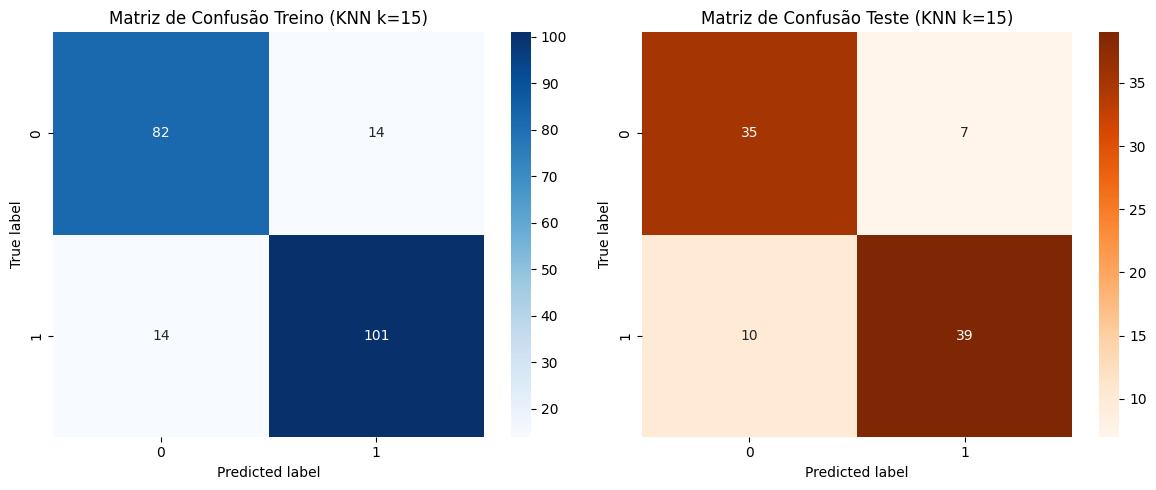

In [301]:
# KNN com Cross-Validation e Seleção de Hiperparâmetros
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

categorical_cols = ['cp','thal','slope','restecg']
X_knn = pd.get_dummies(heart_ds.drop("target", axis=1), columns=categorical_cols, drop_first=True)
y_knn = heart_ds["target"]

# Divisão treino/teste
X_train, X_test, y_train, y_test = train_test_split(X_knn, y_knn, test_size=0.3, random_state=42, stratify=y_knn)

# Hiperparâmetros para teste
k_values = [1, 3, 5, 7, 9, 11, 15, 21]
metrics = ['euclidean', 'manhattan', 'chebyshev', 'minkowski', 'cosine']

# Cross-validation externa (5-fold)
skf_outer = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = []

print("KNN - Cross-Validation com Seleção de Hiperparâmetros")
print("="*60)

for fold, (train_idx, val_idx) in enumerate(skf_outer.split(X_train, y_train), 1):
    X_tr_fold, X_val_fold = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_tr_fold, y_val_fold = y_train.iloc[train_idx], y_train.iloc[val_idx]
    
    # Normalização por fold
    scaler = StandardScaler()
    X_tr_scaled = scaler.fit_transform(X_tr_fold)
    X_val_scaled = scaler.transform(X_val_fold)
    
    # Cross-validation interna para seleção de hiperparâmetros
    skf_inner = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    
    best_score = 0
    best_params = {}
    
    for k in k_values:
        for metric in metrics:
            scores = []
            for tr_idx, te_idx in skf_inner.split(X_tr_scaled, y_tr_fold):
                X_tr_inner, X_te_inner = X_tr_scaled[tr_idx], X_tr_scaled[te_idx]
                y_tr_inner, y_te_inner = y_tr_fold.iloc[tr_idx], y_tr_fold.iloc[te_idx]
                
                try:
                    knn = KNeighborsClassifier(n_neighbors=k, metric=metric)
                    knn.fit(X_tr_inner, y_tr_inner)
                    y_pred = knn.predict(X_te_inner)
                    scores.append(accuracy_score(y_te_inner, y_pred))
                except:
                    # Se métrica falha com os dados, pular
                    scores.append(0)
            
            mean_score = np.mean(scores)
            if mean_score > best_score:
                best_score = mean_score
                best_params = {'k': k, 'metric': metric}
    
    # Treinar melhor modelo no fold completo
    best_knn = KNeighborsClassifier(n_neighbors=best_params['k'], metric=best_params['metric'])
    best_knn.fit(X_tr_scaled, y_tr_fold)
    
    # Avaliar no fold de validação
    y_pred_fold = best_knn.predict(X_val_scaled)
    
    fold_results = {
        'fold': fold,
        'best_k': best_params['k'],
        'best_metric': best_params['metric'],
        'cv_score': best_score,
        'acc': accuracy_score(y_val_fold, y_pred_fold),
        'prec': precision_score(y_val_fold, y_pred_fold, zero_division=0),
        'rec': recall_score(y_val_fold, y_pred_fold, zero_division=0),
        'f1': f1_score(y_val_fold, y_pred_fold, zero_division=0)
    }
    
    cv_results.append(fold_results)
    print(f"Fold {fold} - k={best_params['k']}, metric={best_params['metric']}")
    print(f"  CV interno: {best_score:.3f} | Acc: {fold_results['acc']:.3f} | Prec: {fold_results['prec']:.3f} | Rec: {fold_results['rec']:.3f} | F1: {fold_results['f1']:.3f}")

# Calcular médias
cv_df = pd.DataFrame(cv_results)
mean_results = {
    'acc_mean': cv_df['acc'].mean(),
    'acc_std': cv_df['acc'].std(),
    'prec_mean': cv_df['prec'].mean(),
    'prec_std': cv_df['prec'].std(),
    'rec_mean': cv_df['rec'].mean(),
    'rec_std': cv_df['rec'].std(),
    'f1_mean': cv_df['f1'].mean(),
    'f1_std': cv_df['f1'].std()
}

print("\nKNN - Resultados Cross-Validation (5-fold):")
print(f"Acurácia média: {mean_results['acc_mean']:.3f} ± {mean_results['acc_std']:.3f}")
print(f"Precisão média: {mean_results['prec_mean']:.3f} ± {mean_results['prec_std']:.3f}")
print(f"Recall médio:   {mean_results['rec_mean']:.3f} ± {mean_results['rec_std']:.3f}")
print(f"F1 médio:       {mean_results['f1_mean']:.3f} ± {mean_results['f1_std']:.3f}")

# Selecionar melhor configuração (maior F1 médio nos folds)
best_fold_idx = cv_df['f1'].idxmax()
final_best_k = cv_df.loc[best_fold_idx, 'best_k']
final_best_metric = cv_df.loc[best_fold_idx, 'best_metric']

print(f"\nMelhor configuração: k={final_best_k}, métrica={final_best_metric}")

# Treinar modelo final no conjunto de treino completo
scaler_final = StandardScaler()
X_train_scaled = scaler_final.fit_transform(X_train)
X_test_scaled = scaler_final.transform(X_test)

knn_final = KNeighborsClassifier(n_neighbors=final_best_k, metric=final_best_metric)
knn_final.fit(X_train_scaled, y_train)

# Avaliação final
y_pred_train_final = knn_final.predict(X_train_scaled)
y_pred_test_final = knn_final.predict(X_test_scaled)

print(f"\nKNN — Avaliação Final (k={final_best_k}, {final_best_metric}):")
print(f"Treino: Acc={accuracy_score(y_train, y_pred_train_final):.3f} | Prec={precision_score(y_train, y_pred_train_final):.3f} | Rec={recall_score(y_train, y_pred_train_final):.3f} | F1={f1_score(y_train, y_pred_train_final):.3f}")
print(f"Teste : Acc={accuracy_score(y_test, y_pred_test_final):.3f} | Prec={precision_score(y_test, y_pred_test_final):.3f} | Rec={recall_score(y_test, y_pred_test_final):.3f} | F1={f1_score(y_test, y_pred_test_final):.3f}")

# Matrizes de confusão
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Treino
cm_train = confusion_matrix(y_train, y_pred_train_final)
sns.heatmap(cm_train, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title(f'Matriz de Confusão Treino (KNN k={final_best_k})')
axes[0].set_xlabel('Predicted label')
axes[0].set_ylabel('True label')

# Teste
cm_test = confusion_matrix(y_test, y_pred_test_final)
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Oranges', ax=axes[1])
axes[1].set_title(f'Matriz de Confusão Teste (KNN k={final_best_k})')
axes[1].set_xlabel('Predicted label')
axes[1].set_ylabel('True label')

plt.tight_layout()
plt.show()

# Salvar resultados para comparação
knn_cv_results = mean_results.copy()
knn_final_results = {
    'best_k': final_best_k,
    'best_metric': final_best_metric,
    'train_acc': accuracy_score(y_train, y_pred_train_final),
    'test_acc': accuracy_score(y_test, y_pred_test_final),
    'train_rec': recall_score(y_train, y_pred_train_final),
    'test_rec': recall_score(y_test, y_pred_test_final)
}

### SVM

Acurácia: 0.626


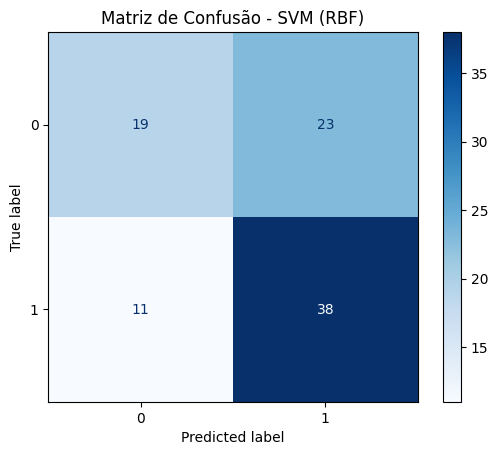

In [302]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

svm = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
svm.fit(X_train, y_train)

y_pred_svm = svm.predict(X_test)
acc_svm = accuracy_score(y_test, y_pred_svm)

print(f"Acurácia: {acc_svm:.3f}")

cm_svm = confusion_matrix(y_test, y_pred_svm)
disp_svm = ConfusionMatrixDisplay(confusion_matrix=cm_svm)
disp_svm.plot(cmap="Blues")
plt.title("Matriz de Confusão - SVM (RBF)")
plt.show()


### Rede Neural:


===== FOLD 1 =====
Epoch  50 | Loss: 2.5695 | Train Acc: 0.793 | Val Acc: 0.672 | Train Recall: 0.963 | Val Recall: 0.966
Epoch 100 | Loss: 1.6398 | Train Acc: 0.826 | Val Acc: 0.721 | Train Recall: 0.956 | Val Recall: 0.931
→ Early stopping at epoch 106
✅ Fold 1: Train Acc = 0.830 | Val Acc = 0.721 | Train Recall = 0.963 | Val Recall = 0.931


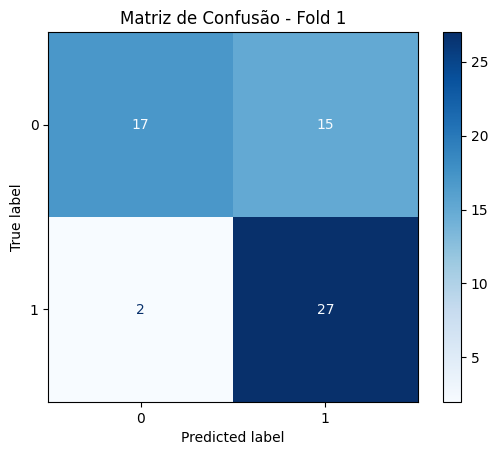


===== FOLD 2 =====
→ Early stopping at epoch 40
✅ Fold 2: Train Acc = 0.809 | Val Acc = 0.869 | Train Recall = 0.902 | Val Recall = 0.906


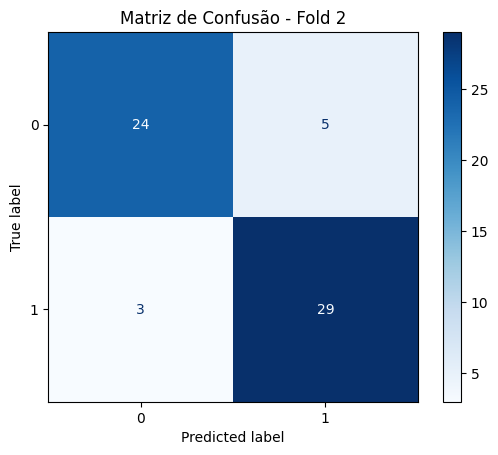


===== FOLD 3 =====
Epoch  50 | Loss: 2.3549 | Train Acc: 0.793 | Val Acc: 0.900 | Train Recall: 0.929 | Val Recall: 0.973
→ Early stopping at epoch 51
✅ Fold 3: Train Acc = 0.793 | Val Acc = 0.900 | Train Recall = 0.929 | Val Recall = 0.973


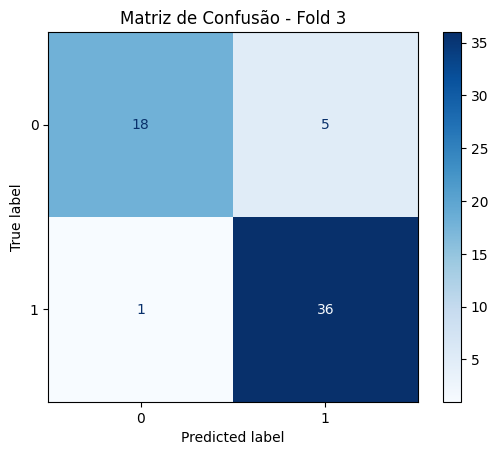


===== FOLD 4 =====
Epoch  50 | Loss: 2.3287 | Train Acc: 0.727 | Val Acc: 0.717 | Train Recall: 0.992 | Val Recall: 0.970
Epoch 100 | Loss: 1.4725 | Train Acc: 0.822 | Val Acc: 0.800 | Train Recall: 0.992 | Val Recall: 0.939
→ Early stopping at epoch 104
✅ Fold 4: Train Acc = 0.822 | Val Acc = 0.800 | Train Recall = 0.992 | Val Recall = 0.939


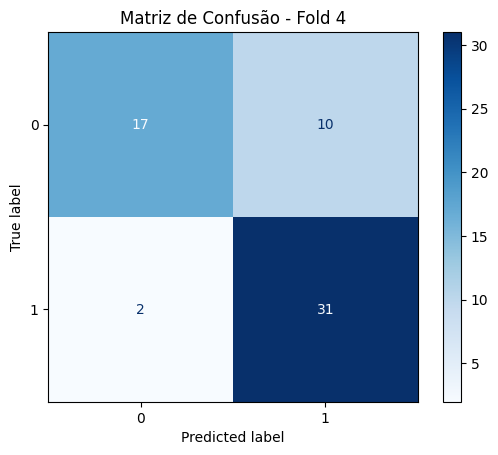


===== FOLD 5 =====
Epoch  50 | Loss: 2.6857 | Train Acc: 0.810 | Val Acc: 0.883 | Train Recall: 0.885 | Val Recall: 0.970
→ Early stopping at epoch 56
✅ Fold 5: Train Acc = 0.818 | Val Acc = 0.917 | Train Recall = 0.893 | Val Recall = 0.970


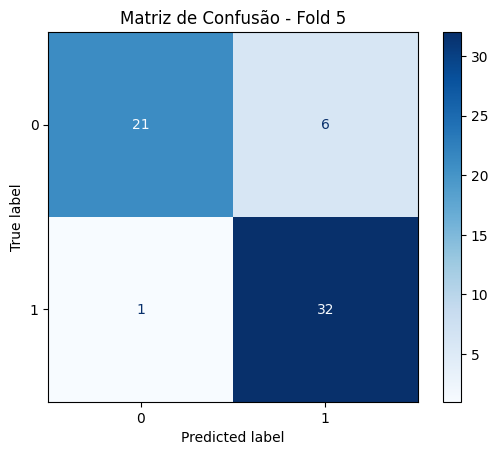


Acurácias de treino: [0.83, 0.809, 0.793, 0.822, 0.818]
Acurácias de validação: [0.721, 0.869, 0.9, 0.8, 0.917]
Recalls de treino: [0.963, 0.902, 0.929, 0.992, 0.893]
Recalls de validação: [0.931, 0.906, 0.973, 0.939, 0.97]
------------------------------------
Média treino: 0.815 ± 0.013
Média validação: 0.841 ± 0.072
Média recall treino: 0.936 ± 0.037
Média recall validação: 0.944 ± 0.025


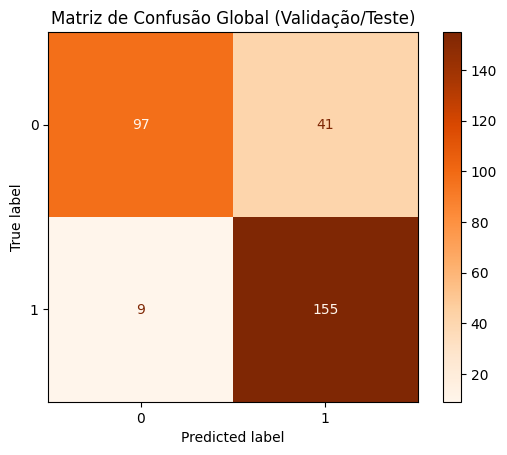

In [303]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, recall_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import KFold
import numpy as np
import matplotlib.pyplot as plt
import random


seed = 42
np.random.seed(seed)
random.seed(seed)
torch.manual_seed(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False


X = heart_ds.drop("target", axis=1).to_numpy()
y = heart_ds["target"].to_numpy()

scaler = StandardScaler()
X = scaler.fit_transform(X)


class SimpleNN(nn.Module):
    def __init__(self, input_dim):
        super(SimpleNN, self).__init__()
        self.hidden = nn.Linear(input_dim, 8)
        self.output = nn.Linear(8, 1)
        self.dropout = nn.Dropout(0.2)
        self.activation = nn.Tanh()
        
    def forward(self, x):
        x = self.hidden(x)
        x = self.activation(x)
        x = self.dropout(x)
        x = self.output(x)
        return x


def train_fold(model, X_train, y_train, X_val, y_val, epochs=500, patience=25):
    pos_weight = torch.tensor([10], dtype=torch.float32)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    optimizer = optim.Adam(model.parameters(), lr=0.002, weight_decay=1e-3)

    best_acc_val = 0
    counter = 0
    best_weights = None

    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        outputs = model(X_train)
        loss = criterion(outputs, y_train)
        loss.backward()
        optimizer.step()

        # === Avaliação ===
        model.eval()
        with torch.no_grad():
            preds_train = (torch.sigmoid(model(X_train)) > 0.5).float()
            preds_val = (torch.sigmoid(model(X_val)) > 0.5).float()

            acc_train = accuracy_score(y_train, preds_train)
            acc_val = accuracy_score(y_val, preds_val)
            recall_train = recall_score(y_train, preds_train)
            recall_val = recall_score(y_val, preds_val)

        # Early stopping
        if acc_val > best_acc_val:
            best_acc_val = acc_val
            best_weights = model.state_dict().copy()
            counter = 0
        else:
            counter += 1

        if (epoch + 1) % 50 == 0:
            print(f"Epoch {epoch+1:3d} | Loss: {loss.item():.4f} | "
                  f"Train Acc: {acc_train:.3f} | Val Acc: {acc_val:.3f} | "
                  f"Train Recall: {recall_train:.3f} | Val Recall: {recall_val:.3f}")

        if counter >= patience:
            print(f"→ Early stopping at epoch {epoch+1}")
            break
    
    model.load_state_dict(best_weights)
    return acc_train, best_acc_val, recall_train, recall_val


kf = KFold(n_splits=5, shuffle=True, random_state=seed)
fold_results = []
all_y_true = []
all_y_pred = []

for fold, (train_idx, val_idx) in enumerate(kf.split(X), 1):
    print(f"\n===== FOLD {fold} =====")

    X_train_fold = torch.tensor(X[train_idx], dtype=torch.float32)
    y_train_fold = torch.tensor(y[train_idx], dtype=torch.float32).unsqueeze(1)
    X_val_fold = torch.tensor(X[val_idx], dtype=torch.float32)
    y_val_fold = torch.tensor(y[val_idx], dtype=torch.float32).unsqueeze(1)

    model = SimpleNN(X.shape[1])
    acc_train, acc_val, recall_train, recall_val = train_fold(
        model, X_train_fold, y_train_fold, X_val_fold, y_val_fold
    )

    fold_results.append((acc_train, acc_val, recall_train, recall_val))
    print(f"✅ Fold {fold}: Train Acc = {acc_train:.3f} | Val Acc = {acc_val:.3f} | "
          f"Train Recall = {recall_train:.3f} | Val Recall = {recall_val:.3f}")


    model.eval()
    with torch.no_grad():
        preds_val_final = (torch.sigmoid(model(X_val_fold)) > 0.5).float()
        cm = confusion_matrix(y_val_fold, preds_val_final)
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
        disp.plot(cmap=plt.cm.Blues)
        plt.title(f"Matriz de Confusão - Fold {fold}")
        plt.show()

        all_y_true.append(y_val_fold.numpy())
        all_y_pred.append(preds_val_final.numpy())


train_accs = [r[0] for r in fold_results]
val_accs = [r[1] for r in fold_results]
train_recalls = [r[2] for r in fold_results]
val_recalls = [r[3] for r in fold_results]

print("\n====================================")
print(f"Acurácias de treino: {[round(a,3) for a in train_accs]}")
print(f"Acurácias de validação: {[round(a,3) for a in val_accs]}")
print(f"Recalls de treino: {[round(r,3) for r in train_recalls]}")
print(f"Recalls de validação: {[round(r,3) for r in val_recalls]}")
print("------------------------------------")
print(f"Média treino: {np.mean(train_accs):.3f} ± {np.std(train_accs):.3f}")
print(f"Média validação: {np.mean(val_accs):.3f} ± {np.std(val_accs):.3f}")
print(f"Média recall treino: {np.mean(train_recalls):.3f} ± {np.std(train_recalls):.3f}")
print(f"Média recall validação: {np.mean(val_recalls):.3f} ± {np.std(val_recalls):.3f}")
print("====================================")


all_y_true = np.concatenate(all_y_true)
all_y_pred = np.concatenate(all_y_pred)

cm_global = confusion_matrix(all_y_true, all_y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_global, display_labels=[0, 1])
disp.plot(cmap=plt.cm.Oranges)
plt.title("Matriz de Confusão Global (Validação/Teste)")
plt.show()


In [304]:
# Cross-validation summary across models (5-fold Stratified)
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Use existing dataframe if available in kernel, otherwise load
try:
    data = heart_ds.copy()
    print("Using 'heart_ds' from kernel")
except Exception:
    try:
        data = df.copy()
        print("Using 'df' from kernel")
    except Exception:
        data = pd.read_csv('heart.csv')
        print("Loaded 'heart.csv' from disk")

# identify target column
target_col = None
for cand in ['target', 'Target', 'condition', 'Condition', 'y']:
    if cand in data.columns:
        target_col = cand
        break
if target_col is None:
    # fallback: assume last column is target
    target_col = data.columns[-1]
    print(f"Target column inferred as '{target_col}'")

y = data[target_col]
X = data.drop(columns=[target_col]).copy()

# categorical columns used earlier
categorical_cols = [c for c in ['cp','thal','slope','restecg'] if c in X.columns]
X_enc = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

# continuous numeric columns
numeric_cols = X_enc.select_dtypes(include=[np.number]).columns.tolist()

# Prepare models
models = {
    'Logistic (approx unreg)': LogisticRegression(C=1e6, solver='lbfgs', max_iter=10000),
    'Ridge (L2)': LogisticRegression(penalty='l2', C=1.0, solver='lbfgs', max_iter=10000),
    'Lasso (L1)': LogisticRegression(penalty='l1', C=1.0, solver='saga', max_iter=10000),
    'LDA': LinearDiscriminantAnalysis(),
    'QDA': QuadraticDiscriminantAnalysis(),
    'KNN (k=5)': KNeighborsClassifier(n_neighbors=5),
    'SVM (RBF)': SVC(kernel='rbf', probability=False)
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = []

for name, model in models.items():
    accs, precs, recs, f1s = [], [], [], []
    for train_idx, test_idx in skf.split(X_enc, y):
        X_tr, X_te = X_enc.iloc[train_idx].copy(), X_enc.iloc[test_idx].copy()
        y_tr, y_te = y.iloc[train_idx], y.iloc[test_idx]

        # scale numeric cols per fold
        scaler = StandardScaler()
        X_tr[numeric_cols] = scaler.fit_transform(X_tr[numeric_cols])
        X_te[numeric_cols] = scaler.transform(X_te[numeric_cols])

        # fit
        try:
            model.fit(X_tr, y_tr)
            y_pred = model.predict(X_te)
        except Exception as e:
            # if model fails (e.g., QDA singular), record NaNs
            print(f"Model {name} failed on a fold: {e}")
            y_pred = np.zeros_like(y_te)

        accs.append(accuracy_score(y_te, y_pred))
        precs.append(precision_score(y_te, y_pred, zero_division=0))
        recs.append(recall_score(y_te, y_pred, zero_division=0))
        f1s.append(f1_score(y_te, y_pred, zero_division=0))

    results.append({
        'model': name,
        'acc_mean': np.mean(accs), 'acc_std': np.std(accs),
        'prec_mean': np.mean(precs), 'prec_std': np.std(precs),
        'rec_mean': np.mean(recs), 'rec_std': np.std(recs),
        'f1_mean': np.mean(f1s), 'f1_std': np.std(f1s)
    })

res_df = pd.DataFrame(results).set_index('model')
# format results
res_fmt = res_df.copy()
for col in ['acc_mean','prec_mean','rec_mean','f1_mean']:
    std_col = col.replace('_mean','_std')
    res_fmt[col] = res_df[col].round(3).astype(str) + ' ± ' + res_df[std_col].round(3).astype(str)

display(res_fmt[['acc_mean','prec_mean','rec_mean','f1_mean']])

# Save to notebook variable for later referencing
cv_summary = res_df

# Also print sorted by recall mean (important for minimizing false negatives)
print('\nModels sorted by mean Recall:')
print(res_df.sort_values('rec_mean', ascending=False)[['rec_mean','rec_std']])

Using 'heart_ds' from kernel


/home/al.igor.alves/anaconda3/envs/ambiente_aluno/lib/python3.9/site-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 1 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
/home/al.igor.alves/anaconda3/envs/ambiente_aluno/lib/python3.9/site-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 0 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
/home/al.igor.alves/anaconda3/envs/ambiente_aluno/lib/python3.9/site-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 1 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
/home/al.igor.alves/anaconda3/envs/ambiente_aluno/lib/python3.9/site-packages/sklearn/discriminant_analysis.py:1052: RuntimeWarning: divide by zero 

,acc_mean,prec_mean,rec_mean,f1_mean
model,,,,
Logistic (approx unreg),0.821 ± 0.043,0.825 ± 0.03,0.853 ± 0.099,0.835 ± 0.05
Ridge (L2),0.841 ± 0.032,0.846 ± 0.045,0.872 ± 0.093,0.854 ± 0.037
Lasso (L1),0.838 ± 0.037,0.83 ± 0.028,0.884 ± 0.085,0.853 ± 0.04
LDA,0.831 ± 0.035,0.822 ± 0.033,0.884 ± 0.089,0.848 ± 0.04
QDA,0.64 ± 0.15,0.649 ± 0.143,0.726 ± 0.353,0.624 ± 0.291
KNN (k=5),0.811 ± 0.03,0.831 ± 0.045,0.823 ± 0.057,0.825 ± 0.031
SVM (RBF),0.851 ± 0.014,0.862 ± 0.048,0.872 ± 0.067,0.863 ± 0.017



Models sorted by mean Recall:
                         rec_mean   rec_std
model                                      
LDA                      0.883902  0.089067
Lasso (L1)               0.883712  0.085337
SVM (RBF)                0.871970  0.067437
Ridge (L2)               0.871591  0.093403
Logistic (approx unreg)  0.853220  0.099402
KNN (k=5)                0.822727  0.057416
QDA                      0.726136  0.353106
